# Estudo de Caso 4 — Eficiência da Conciliação Obrigatória no 4.º JEC de Natal/RN

**Arquivos de entrada**
- `dat/estcaso_4JEC_natal/ControleDosProcessos_Mestrado_Atualizacao_07.10.2026.xlsx`
- `txt/24_09-TrabalhoEmpirico-PauloGiovani-Enajus2026-FINAL-cleuler-corrigido.docx`
- `txt/limitacoes_experimento_4_JEC_Natal.odt`

**Referências metodológicas** · `rafaelcc_ed1.ipynb` (pipeline-modelo) · `estcaso_ip.ipynb` (estudo-base)

---

## Objetivo

Este notebook constitui um **estudo de caso completo** sobre o tempo de tramitação processual no **4.º Juizado Especial Cível (JEC) de Natal/RN**, no período de 1.º de janeiro a 3 de agosto de 2026.  
O experimento compara três **grupos de tratamento** definidos por sorteio aleatório de rito:

| Grupo | Rito sorteado | Papel |
|---|---|---|
| Controle | Rito Atual — Audiência de Conciliação (AC) Opcional | Linha de base |
| Tratamento 1 | AC Obrigatória Presencial | Intervenção |
| Tratamento 2 | AC Remota | Intervenção |

A **variável-resposta principal** é o **tempo de tramitação** (em dias), com atenção especial para:
- **Censura à direita** — processos ainda ativos ao final da janela de observação;
- **Assimetria** das distribuições de tempo;
- **Robustez inferencial** via testes não paramétricos e análise de sobrevivência (Kaplan-Meier).

A estrutura analítica segue o fluxo completo de `rafaelcc_ed1.ipynb`:  
preparação → limpeza → tipagem → auditoria → análise descritiva (categóricas e quantitativas) → comparação por grupos → associação entre categóricas → correlação entre quantitativas → normalidade → testes de hipóteses → ajuste de distribuições → regressão → sobrevivência → síntese.

## 1. Tipos de Gráficos — Introdução Visual

Antes de manipular os dados, é útil mapear qual recurso visual será empregado em cada situação analítica.

| Gráfico | Tipo de variável | Finalidade analítica |
|---|---|---|
| Barras / Pareto | Categórica | Avaliar frequências e concentração de categorias |
| Histograma + KDE | Quantitativa | Examinar forma, dispersão e assimetria |
| Boxplot / Violin | Quantitativa por grupos | Comparar posição, dispersão e valores extremos |
| Mosaico | Categ. × Categ. | Investigar associação entre categorias |
| Dispersão + Regressão | Quant. × Quant. | Identificar tendência e intensidade de relação |
| Kaplan-Meier | Tempo até evento | Modelar tramitação com dados censurados |

### 1.1 Gráfico de Barras / Pareto
**Quando usar:** distribuição de variáveis **categóricas**.  
**Como interpretar:** cada barra mostra a frequência de uma categoria; a curva acumulada (Pareto) indica quais categorias concentram 80 % dos casos.

### 1.2 Histograma + KDE
**Quando usar:** variáveis **quantitativas** com amostras grandes.  
**Como interpretar:** forma (simétrica / assimétrica), centro (média vs. mediana) e dispersão (amplitude do histograma).

### 1.3 Boxplot
**Quando usar:** variáveis **quantitativas**, especialmente para comparar grupos.  
**Como interpretar:** caixa = IQR (50 % centrais); linha vermelha = mediana; losango = média; pontos além dos bigodes = potenciais outliers.

### 1.4 Gráfico Mosaico
**Quando usar:** relação entre duas variáveis **categóricas**.  
**Como interpretar:** área de cada retângulo proporcional à frequência conjunta; padrões que desviam da independência indicam associação.

### 1.5 Diagrama de Dispersão
**Quando usar:** relação entre duas variáveis **quantitativas**.  
**Como interpretar:** direção (positiva/negativa), força (pontos próximos ou dispersos), reta de mínimos quadrados.

### 1.6 Curva de Kaplan-Meier
**Quando usar:** **tempo até evento** com possibilidade de censura.  
**Como interpretar:** queda da curva = evento ocorrido (processo encerrado); platôs = processos ainda ativos (censurados). Mediana = tempo em que 50 % dos processos foram encerrados.

## 2. Preparação do Ambiente

**Objetivo desta etapa:** importar todas as bibliotecas necessárias e definir os caminhos de entrada/saída para garantir a **reprodutibilidade** do pipeline.  

> **Atenção:** confirme que todas as bibliotecas são carregadas sem erros e que os arquivos de entrada são encontrados nos caminhos indicados.

In [1]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Importar bibliotecas e dependências necessárias.
# 2) Definir caminhos de entrada e saída usados no estudo.
# 3) Exibir saídas intermediárias para validação da etapa.
# ───────────────────────────────────────────────────────────────────────────

from pathlib import Path
import warnings
import re
import unicodedata
import zipfile
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Bibliotecas opcionais ──────────────────────────────────────────────────
try:
    import statsmodels.api as sm
    from statsmodels.graphics.mosaicplot import mosaic
    TEM_STATSMODELS = True
except ImportError:
    sm = None
    mosaic = None
    TEM_STATSMODELS = False

try:
    from lifelines import KaplanMeierFitter, logrank_test
    TEM_LIFELINES = True
except ImportError:
    KaplanMeierFitter = None
    logrank_test = None
    TEM_LIFELINES = False

# ── Configurações globais de visualização ─────────────────────────────────
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Caminhos de entrada e saída ────────────────────────────────────────────
# Ajusta a raiz do projeto para o diretório pai de 'notebooks/'
BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

DADOS_XLSX = BASE / 'dat' / 'estcaso_4JEC_natal' / 'ControleDosProcessos_Mestrado_Atualizacao_07.10.2026.xlsx'
TEXTO_DOCX = BASE / 'txt' / '24_09-TrabalhoEmpirico-PauloGiovani-Enajus2026-FINAL-cleuler-corrigido.docx'
TEXTO_ODT  = BASE / 'txt' / 'limitacoes_experimento_4_JEC_Natal.odt'
SAIDA_DIR  = BASE / 'dat' / 'processado'
SAIDA_DIR.mkdir(parents=True, exist_ok=True)

# ── Verificação de existência dos arquivos ─────────────────────────────────
print('=' * 60)
print('VERIFICAÇÃO DO AMBIENTE')
print('=' * 60)
print(f'Raiz do projeto  : {BASE}')
print(f'Planilha XLSX    : {DADOS_XLSX.exists()} → {DADOS_XLSX.name}')
print(f'Texto DOCX       : {TEXTO_DOCX.exists()} → {TEXTO_DOCX.name}')
print(f'Texto ODT        : {TEXTO_ODT.exists()} → {TEXTO_ODT.name}')
print(f'Saída            : {SAIDA_DIR}')
print(f'statsmodels      : {TEM_STATSMODELS}')
print(f'lifelines        : {TEM_LIFELINES}')
print()
print('Ambiente configurado com sucesso!')

VERIFICAÇÃO DO AMBIENTE
Raiz do projeto  : e:\DADOS\Documents\AmbienteDeTrabalho\Projetos\notebook
Planilha XLSX    : True → ControleDosProcessos_Mestrado_Atualizacao_07.10.2026.xlsx
Texto DOCX       : True → 24_09-TrabalhoEmpirico-PauloGiovani-Enajus2026-FINAL-cleuler-corrigido.docx
Texto ODT        : True → limitacoes_experimento_4_JEC_Natal.odt
Saída            : e:\DADOS\Documents\AmbienteDeTrabalho\Projetos\notebook\dat\processado
statsmodels      : True
lifelines        : False

Ambiente configurado com sucesso!


## 3. Leitura dos Textos Metodológicos (DOCX e ODT)

**Objetivo:** extrair e exibir trechos dos documentos de contexto —  
o artigo empírico (DOCX) e o documento de limitações do experimento (ODT) —  
para fundamentar as escolhas analíticas das seções seguintes.

> **Atenção:** observe se os trechos impressos estão legíveis e coerentes com o contexto do estudo.

In [2]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Declarar funções auxiliares de extração de texto.
# 2) Ler os arquivos DOCX e ODT.
# 3) Exibir trechos para validação.
# ───────────────────────────────────────────────────────────────────────────

def extrair_texto_docx(caminho: Path) -> str:
    """Extrai e concatena os parágrafos de um arquivo .docx."""
    ns = {'w': 'http://schemas.openxmlformats.org/wordprocessingml/2006/main'}
    with zipfile.ZipFile(caminho) as z:
        root = ET.fromstring(z.read('word/document.xml'))
    paragrafos = []
    for p in root.findall('.//w:p', ns):
        partes = [t.text for t in p.findall('.//w:t', ns) if t.text]
        if partes:
            paragrafos.append(''.join(partes))
    return '\n'.join(paragrafos)

def extrair_texto_odt(caminho: Path) -> str:
    """Extrai texto de um arquivo .odt (formato OpenDocument)."""
    with zipfile.ZipFile(caminho) as z:
        root = ET.fromstring(z.read('content.xml'))
    trechos = [el.text.strip() for el in root.iter() if el.text and el.text.strip()]
    return '\n'.join(trechos)

def normalizar(txt: str) -> str:
    """Remove múltiplos espaços e quebras desnecessárias."""
    return re.sub(r'\s+', ' ', txt).strip()

# ── Leitura dos arquivos ───────────────────────────────────────────────────
texto_docx = extrair_texto_docx(TEXTO_DOCX)
texto_odt  = extrair_texto_odt(TEXTO_ODT)

print('=' * 70)
print('RESUMO DO ARTIGO EMPÍRICO (DOCX) — primeiros 1 200 caracteres')
print('=' * 70)
print(normalizar(texto_docx)[:1200])

print()
print('=' * 70)
print('LIMITAÇÕES DO EXPERIMENTO (ODT) — primeiros 1 200 caracteres')
print('=' * 70)
print(normalizar(texto_odt)[:1200])

RESUMO DO ARTIGO EMPÍRICO (DOCX) — primeiros 1 200 caracteres
Eficácia da Conciliação Obrigatória na Tramitação Processual: um Experimento no 4º Juizado Especial Cível de Natal (2026) Paulo Giovani Militão de Alencar – Universidade Federal de Goiás Cleuler Barbosa das Neves – Universidade Federal de Goiás Tema de interesse: Métodos alternativos de solução de demandas judiciais RESUMO O presente trabalho empírico busca avaliar a conciliação como política pública levada a efeito nacionalmente pelo Conselho Nacional de Justiça, por meio da Resolução nº 125/2010, bem como, em nível local, pelo Tribunal de Justiça do Rio Grande do Norte. A conciliação surge como esperança no enfrentamento da morosidade judicial na tramitação dos processos, despontando legalmente como princípio basilar dos juizados especiais cíveis no artigo 2º da Lei nº 9.099/1995 e sendo posteriormente erguida à condição de Política Pública Judiciária pela Resolução CNJ nº 125/2010, que delineou para os tribunais o caminho

## 4. Criação do Dataset — Leitura da Planilha

**Objetivo:** carregar a aba **Processos** da planilha XLSX, identificar o cabeçalho real (linha 2 da planilha, índice 1 no DataFrame bruto) e inspecionar as dimensões, colunas e primeiras linhas.

> **Atenção:** verifique dimensões, nomes das colunas e presença de valores faltantes logo na leitura inicial.

In [3]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Ler a planilha sem assumir cabeçalho automático (header=None).
# 2) Extrair o cabeçalho real da linha de índice 1.
# 3) Montar o DataFrame de dados a partir da linha de índice 2.
# 4) Exibir dimensões e primeiras linhas.
# ───────────────────────────────────────────────────────────────────────────

# Leitura bruta — a linha 0 é um título mesclado, a linha 1 é o cabeçalho
raw = pd.read_excel(DADOS_XLSX, sheet_name='Processos', header=None)

# Cabeçalho original (linha índice 1)
cabecalho_original = raw.iloc[1].fillna('').astype(str).str.strip()

# Dados a partir da linha índice 2
dados_brutos = raw.iloc[2:].copy()
dados_brutos.columns = cabecalho_original
dados_brutos = dados_brutos.dropna(how='all').reset_index(drop=True)

print(f'Dimensão bruta: {dados_brutos.shape[0]} linhas × {dados_brutos.shape[1]} colunas')
print('\nColunas originais:')
for i, c in enumerate(dados_brutos.columns):
    print(f'  {i:2d}: {c}')

print('\nPrimeiras 5 linhas:')
display(dados_brutos.head())

print('\nInformações de tipos:')
dados_brutos.info()

Dimensão bruta: 944 linhas × 15 colunas

Colunas originais:
   0: NÚMERO DO PROCESSO
   1: DT. DISTRIBUIÇÃO
   2: SORTEIO
   3: HÍBRIDA
   4: TEVE ACORDO NA AC?
   5: TÉCNICA
   6: TEVE ACORDO FORA DA AC?
   7: SENTENÇA
   8: DT. SENTENÇA
   9: DURAÇÃO-SENT2
  10: DURAÇÃO-TECN
  11: DURAÇÃO-SORT
  12: DURAÇÃO-PROC
  13: DURAÇÃO DO PROCESSO
  14: STATUS

Primeiras 5 linhas:


1,NÚMERO DO PROCESSO,DT. DISTRIBUIÇÃO,SORTEIO,HÍBRIDA,TEVE ACORDO NA AC?,TÉCNICA,TEVE ACORDO FORA DA AC?,SENTENÇA,DT. SENTENÇA,DURAÇÃO-SENT2,DURAÇÃO-TECN,DURAÇÃO-SORT,DURAÇÃO-PROC,DURAÇÃO DO PROCESSO,STATUS
0,0800001-35.2026.8.20.5004,2026-01-01 00:00:00,Rito Atual Ac Opcional,Não,Não,**,Não,Extinção do feito sem julgamento de mérito,2026-01-07 00:00:00,6,NaN,6,6,6 dia(s),Encerrado
1,0800024-78.2026.8.20.5004,2026-01-06 00:00:00,Rito Atual Ac Opcional,Não,Não,**,NaN,NaN,NaN,274,NaN,274,274,274 dia(s),Ativo
2,0808292-43.2025.8.20.5300,2026-01-06 00:00:00,Rito Atual Ac Opcional,Não,Não,**,Não,Extinção do Feito sem Julgamento de Mérito,2026-01-09 00:00:00,3,NaN,3,3,3 dia(s),Encerrado
3,0800038-62.2026.8.20.5004,2026-01-07 00:00:00,Ac Obrigatória Presencial,Não,Sim,Desconstrução da Verdade,Não,Extinção do Feito com Homologação do Acordo,2026-02-22 00:00:00,46,46,46,46,46 dia(s),Encerrado
4,0800035-10.2026.8.20.5004,2026-01-07 00:00:00,Rito Atual Ac Opcional,Não,Não,**,Não,Extinção do Feito com Julgamento de Mérito,2026-02-27 00:00:00,51,NaN,51,51,51 dia(s),Encerrado



Informações de tipos:
<class 'pandas.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   NÚMERO DO PROCESSO       944 non-null    str   
 1   DT. DISTRIBUIÇÃO         944 non-null    object
 2   SORTEIO                  944 non-null    str   
 3   HÍBRIDA                  872 non-null    str   
 4   TEVE ACORDO NA AC?       869 non-null    str   
 5   TÉCNICA                  867 non-null    str   
 6   TEVE ACORDO FORA DA AC?  736 non-null    str   
 7   SENTENÇA                 734 non-null    str   
 8   DT. SENTENÇA             734 non-null    object
 9   DURAÇÃO-SENT2            943 non-null    object
 10  DURAÇÃO-TECN             428 non-null    object
 11  DURAÇÃO-SORT             943 non-null    object
 12  DURAÇÃO-PROC             943 non-null    object
 13  DURAÇÃO DO PROCESSO      943 non-null    str   
 14  STATUS                   943 n

## 5. Limpeza dos Dados — Padronização de Rótulos e Colunas

**Objetivo:** corrigir caracteres corrompidos (*mojibake*) nos nomes das colunas, padronizá-los em *snake_case* e normalizar os valores textuais (remoção de espaços duplos, substituição de strings vazias por `NaN`).

> **Atenção:** compare os nomes originais e padronizados para garantir consistência terminológica ao longo de todo o pipeline.

In [4]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Dicionário de correções para nomes de coluna com mojibake.
# 2) Função de padronização em snake_case.
# 3) Renomear colunas e normalizar valores object.
# 4) Exibir mapeamento e lista de colunas resultante.
# ───────────────────────────────────────────────────────────────────────────

# Mapeamento de nomes corrompidos → nomes legíveis antes da conversão
CORRECOES_COLUNA = {
    'N\ufffdMERO DO PROCESSO'  : 'NUMERO DO PROCESSO',
    'DT. DISTRIBUI\ufffd\ufffdO': 'DT. DISTRIBUICAO',
    'H\ufffdBRIDA'             : 'HIBRIDA',
    'T\ufffdCNICA'             : 'TECNICA',
    'SENTEN\ufffdA'            : 'SENTENCA',
    'DT. SENTEN\ufffdA'        : 'DT. SENTENCA',
    'DURA\ufffd\ufffdO-SENT2'   : 'DURACAO-SENT2',
    'DURA\ufffd\ufffdO-TECN'    : 'DURACAO-TECN',
    'DURA\ufffd\ufffdO-SORT'    : 'DURACAO-SORT',
    'DURA\ufffd\ufffdO-PROC'    : 'DURACAO-PROC',
    ' DURA\ufffd\ufffdO DO PROCESSO': 'DURACAO DO PROCESSO',
}

def slug_coluna(nome: str) -> str:
    """Converte nome de coluna para snake_case ASCII, sem acentos."""
    nome = CORRECOES_COLUNA.get(nome, nome)               # corrige mojibake
    nome = unicodedata.normalize('NFKD', str(nome))       # decompõe acentos
    nome = nome.encode('ascii', 'ignore').decode('ascii')  # remove não-ASCII
    nome = nome.lower().strip()
    nome = re.sub(r'[^a-z0-9]+', '_', nome)               # substitui símbolos por _
    nome = re.sub(r'_+', '_', nome).strip('_')            # remove _ duplos/extremos
    return nome

# Aplicar renomeação
mapa_renomear = {c: slug_coluna(c) for c in dados_brutos.columns}
dados = dados_brutos.rename(columns=mapa_renomear).copy()

# Normalizar strings: remover espaços múltiplos, tratar vazio e 'nan' como NaN
for col in dados.select_dtypes(include='object').columns:
    dados[col] = (
        dados[col]
        .astype(str)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
        .replace({'nan': np.nan, '': np.nan, 'NaN': np.nan})
    )

# Exibir mapeamento
mapa_df = pd.DataFrame({
    'coluna_original' : list(mapa_renomear.keys()),
    'coluna_padronizada': list(mapa_renomear.values())
})
print('Mapeamento de colunas:')
display(mapa_df)
print('\nColunas padronizadas:', list(dados.columns))

Mapeamento de colunas:


,coluna_original,coluna_padronizada
0,NÚMERO DO PROCESSO,numero_do_processo
1,DT. DISTRIBUIÇÃO,dt_distribuicao
2,SORTEIO,sorteio
3,HÍBRIDA,hibrida
4,TEVE ACORDO NA AC?,teve_acordo_na_ac
5,TÉCNICA,tecnica
6,TEVE ACORDO FORA DA AC?,teve_acordo_fora_da_ac
7,SENTENÇA,sentenca
8,DT. SENTENÇA,dt_sentenca
9,DURAÇÃO-SENT2,duracao_sent2



Colunas padronizadas: ['numero_do_processo', 'dt_distribuicao', 'sorteio', 'hibrida', 'teve_acordo_na_ac', 'tecnica', 'teve_acordo_fora_da_ac', 'sentenca', 'dt_sentenca', 'duracao_sent2', 'duracao_tecn', 'duracao_sort', 'duracao_proc', 'duracao_do_processo', 'status']


## 6. Normalização das Categorias — Grupos Experimentais e Status

**Objetivo:** harmonizar as categorias-chave (grupo experimental, status do processo, sentença) para eliminar variações de grafia e criar variáveis analíticas de fácil manipulação.

Os três grupos experimentais surgem da coluna `sorteio`:  
- **Controle** → *Rito Atual Ac Opcional*  
- **Tratamento 1** → *Ac Obrigatória Presencial*  
- **Tratamento 2** → *Ac Remota*

> **Atenção:** valide se os grupos foram mapeados corretamente e se não sobraram categorias residuais.

In [5]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Criar variável 'grupo' a partir de 'sorteio' com rótulos curtos.
# 2) Padronizar 'status' e criar 'status_norm' com valores canônicos.
# 3) Padronizar a coluna 'sentenca' (unificação de caixa).
# 4) Verificar categorias resultantes.
# ───────────────────────────────────────────────────────────────────────────

# ── Grupo experimental ─────────────────────────────────────────────────────
MAPA_GRUPO = {
    'Rito Atual Ac Opcional'       : 'Controle',
    'Ac Obrigat\u00f3ria Presencial': 'Tratamento_presencial',
    'Ac Remota'                    : 'Tratamento_remoto',
    # variantes com mojibake remanescente
    'Ac Obrigat\ufffdria Presencial': 'Tratamento_presencial',
    'Ac Obrigatria Presencial'      : 'Tratamento_presencial',
}
dados['grupo'] = dados['sorteio'].map(MAPA_GRUPO)

# ── Status do processo ──────────────────────────────────────────────────────
MAPA_STATUS = {'Encerrado': 'Encerrado', 'Ativo': 'Ativo'}
dados['status_norm'] = dados['status'].map(MAPA_STATUS).fillna(dados['status'])

# ── Sentença padronizada (caixa uniforme) ───────────────────────────────────
if 'sentenca' in dados.columns:
    dados['sentenca_std'] = (
        dados['sentenca']
        .str.title()          # primeira letra de cada palavra maiúscula
        .str.strip()
    )

# ── Verificação ─────────────────────────────────────────────────────────────
print('Frequências por grupo experimental:')
print(dados['grupo'].value_counts(dropna=False))

print('\nFrequências por status:')
print(dados['status_norm'].value_counts(dropna=False))

if 'sentenca_std' in dados.columns:
    print('\nFrequências por sentença padronizada:')
    print(dados['sentenca_std'].value_counts(dropna=False))

print('\nAmostra da tabela com variáveis criadas:')
display(dados[['sorteio', 'grupo', 'status', 'status_norm']].head(8))

Frequências por grupo experimental:
grupo
Tratamento_presencial    316
Controle                 314
Tratamento_remoto        314
Name: count, dtype: int64

Frequências por status:
status_norm
Encerrado    734
Ativo        209
NaN            1
Name: count, dtype: int64

Frequências por sentença padronizada:
sentenca_std
Extinção Do Feito Com Julgamento De Mérito     341
Extinção Do Feito Sem Julgamento De Mérito     286
NaN                                            210
Extinção Do Feito Com Homologação Do Acordo     81
Decisão                                         26
Name: count, dtype: int64

Amostra da tabela com variáveis criadas:


1,sorteio,grupo,status,status_norm
0,Rito Atual Ac Opcional,Controle,Encerrado,Encerrado
1,Rito Atual Ac Opcional,Controle,Ativo,Ativo
2,Rito Atual Ac Opcional,Controle,Encerrado,Encerrado
3,Ac Obrigatória Presencial,Tratamento_presencial,Encerrado,Encerrado
4,Rito Atual Ac Opcional,Controle,Encerrado,Encerrado
5,Ac Remota,Tratamento_remoto,Encerrado,Encerrado
6,Ac Remota,Tratamento_remoto,Encerrado,Encerrado
7,Rito Atual Ac Opcional,Controle,Encerrado,Encerrado


## 7. Tipagem Final do Dataset

**Objetivo:** converter colunas para os tipos analíticos corretos —  
datas → `datetime`, durações → `int64`/`float64`, categóricas → `category`.

> **Atenção:** após esta etapa, confirme que `dados.dtypes` mostra os tipos esperados antes de prosseguir.

In [7]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Converter colunas de data para datetime.
# 2) Converter colunas de duração para numérico.
# 3) Converter variáveis categóricas para o tipo 'category'.
# 4) Criar variável booleana 'censura' (indicador de censura à direita).
# 5) Exibir dtypes e estatísticas descritivas iniciais.
# ───────────────────────────────────────────────────────────────────────────

# ── Conversão de datas ──────────────────────────────────────────────────────
COLS_DATA = [c for c in ['dt_distribuicao', 'dt_sentenca'] if c in dados.columns]
for c in COLS_DATA:
    dados[c] = pd.to_datetime(dados[c], errors='coerce')

# ── Conversão de durações para int (aceita NaN via float64) ─────────────────
COLS_NUM = [c for c in ['duracao_sent2', 'duracao_tecn', 'duracao_sort', 'duracao_proc']
            if c in dados.columns]
for c in COLS_NUM:
    dados[c] = pd.to_numeric(dados[c], errors='coerce')

# ── Conversão de categóricas ─────────────────────────────────────────────────
COLS_CAT = [c for c in ['grupo', 'status_norm', 'hibrida', 'teve_acordo_na_ac',
                        'teve_acordo_fora_da_ac', 'sentenca_std', 'tecnica']
            if c in dados.columns]
for c in COLS_CAT:
    dados[c] = dados[c].astype('category')

# ── Variável de censura à direita ─────────────────────────────────────────────
# Definição: um processo é CENSURADO (censura = 1) quando NÃO possui sentença
# registrada (sentenca_std é NaN), ou seja, seu tempo real de tramitação é
# desconhecido pois o evento de interesse (encerramento com sentença) não ocorreu
# dentro da janela de observação. Processos COM sentença registrada recebem
# censura = 0 (evento observado). Convenção padrão em análise de sobrevivência:
#   censura = 1  →  tempo incompleto (processo ainda ativo / sem sentença)
#   censura = 0  →  evento ocorrido  (processo encerrado com sentença)
if 'sentenca_std' in dados.columns:
    dados['censura'] = dados['sentenca_std'].isna().astype(int)

# Verificação cruzada com 'status_norm' para consistência interna
# Espera-se que censura=1 coincida com status_norm='Ativo' e
# censura=0 coincida com status_norm='Encerrado'.
if {'censura', 'status_norm'}.issubset(dados.columns):
    print('Distribuição da variável censura:')
    print(dados['censura'].value_counts()
          .rename({0: 'Evento observado  (censura = 0)',
                   1: 'Censurado à direita (censura = 1)'})
          .to_string())
    print()
    print('Tabela cruzada censura × status_norm (consistência):')
    display(pd.crosstab(dados['censura'], dados['status_norm'],
                        rownames=['censura'], colnames=['status_norm'],
                        margins=True))
    print()
    # Alerta se houver linhas inconsistentes
    inconsistentes = (
        (dados['censura'] == 1) & (dados['status_norm'] == 'Encerrado') |
        (dados['censura'] == 0) & (dados['status_norm'] == 'Ativo')
    ).sum()
    print(f'Linhas com censura inconsistente em relação ao status: {inconsistentes}')
    msg = 'OK — censura alinhada ao status.' if inconsistentes == 0 else 'ATENÇÃO — revisar registros inconsistentes.'
    print(msg)

# ── Resumo de tipos ──────────────────────────────────────────────────────────
print('\nTipos das variáveis após tipagem:')
print(dados.dtypes)

print('\nEstatísticas descritivas das variáveis de duração:')
display(
    dados[COLS_NUM].describe(percentiles=[.25, .5, .75, .9, .95]).round(1).T
)

Distribuição da variável censura:
censura
Evento observado  (censura = 0)      734
Censurado à direita (censura = 1)    210

Tabela cruzada censura × status_norm (consistência):


status_norm,Ativo,Encerrado,All
censura,,,
0,0,734,734
1,209,0,209
All,209,734,943



Linhas com censura inconsistente em relação ao status: 0
OK — censura alinhada ao status.

Tipos das variáveis após tipagem:
1
numero_do_processo                   str
dt_distribuicao           datetime64[us]
sorteio                              str
hibrida                         category
teve_acordo_na_ac               category
tecnica                         category
teve_acordo_fora_da_ac          category
sentenca                             str
dt_sentenca               datetime64[us]
duracao_sent2                    float64
duracao_tecn                     float64
duracao_sort                     float64
duracao_proc                     float64
duracao_do_processo                  str
status                               str
grupo                           category
status_norm                     category
sentenca_std                    category
censura                            int64
dtype: object

Estatísticas descritivas das variáveis de duração:


,count,mean,std,min,25%,50%,75%,90%,95%,max
1,,,,,,,,,,
duracao_sent2,943.00,78.50,51.20,0.00,42.00,80.00,110.50,141.00,162.00,274.00
duracao_tecn,428.00,105.80,36.10,1.00,79.00,98.50,126.20,155.30,176.00,257.00
duracao_sort,943.00,78.50,51.20,0.00,42.00,80.00,110.50,141.00,162.00,274.00
duracao_proc,943.00,78.50,51.20,0.00,42.00,80.00,110.50,141.00,162.00,274.00


## 8. Auditoria de Qualidade e Coerência

**Objetivo:** verificar duplicatas de número de processo, valores faltantes nas variáveis principais, durações negativas e inconsistências entre datas e durações calculadas.

> **Atenção:** priorize qualquer inconsistência de data/duração ou chave duplicada antes de prosseguir com as análises.

In [8]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Verificar duplicatas na chave primária (número do processo).
# 2) Contar faltantes nas variáveis analíticas principais.
# 3) Checar durações negativas (incoerência de dados).
# 4) Confrontar durações registradas vs. calculadas por diferença de datas.
# ───────────────────────────────────────────────────────────────────────────

relatorio = {}

# 1) Duplicatas de processo
col_chave = 'numero_do_processo'
if col_chave in dados.columns:
    relatorio['duplicatas_numero_processo'] = int(dados[col_chave].duplicated().sum())

# 2) Faltantes nas variáveis principais
for c in ['dt_distribuicao', 'dt_sentenca', 'duracao_proc', 'status_norm', 'grupo']:
    if c in dados.columns:
        relatorio[f'faltantes_{c}'] = int(dados[c].isna().sum())

# 3) Durações negativas
if 'duracao_proc' in dados.columns:
    relatorio['duracao_proc_negativa'] = int((dados['duracao_proc'] < 0).sum())

# 4) Inconsistência entre datas e duração registrada (tolerância: 2 dias)
if {'dt_distribuicao', 'dt_sentenca', 'duracao_proc'}.issubset(dados.columns):
    dias_calc = (dados['dt_sentenca'] - dados['dt_distribuicao']).dt.days
    dif_abs   = (dias_calc - dados['duracao_proc']).abs()
    relatorio['inconsistencia_data_x_duracao_gt2d'] = int((dif_abs > 2).sum(skipna=True))

# Exibir relatório
rel_df = pd.Series(relatorio, name='quantidade').to_frame()
rel_df['avaliação'] = rel_df['quantidade'].apply(lambda v: 'OK' if v == 0 else 'ATENÇÃO')
print('RELATÓRIO DE AUDITORIA')
print('=' * 50)
display(rel_df)

RELATÓRIO DE AUDITORIA


,quantidade,avaliação
duplicatas_numero_processo,6,ATENÇÃO
faltantes_dt_distribuicao,0,OK
faltantes_dt_sentenca,210,ATENÇÃO
faltantes_duracao_proc,1,ATENÇÃO
faltantes_status_norm,1,ATENÇÃO
faltantes_grupo,0,OK
duracao_proc_negativa,0,OK
inconsistencia_data_x_duracao_gt2d,0,OK


## 9. Exportação do Dataset Limpo

**Objetivo:** salvar o dataset tratado em formato XLSX e CSV para reutilização em outros notebooks ou relatórios, garantindo rastreabilidade do pipeline.

> **Atenção:** confirme o caminho do arquivo salvo; ele será a base reprodutível de todas as análises seguintes.

In [9]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Salvar dataset limpo em XLSX (para inspeção humana).
# 2) Salvar em CSV UTF-8 (para interoperabilidade).
# 3) Confirmar os caminhos de saída.
# ───────────────────────────────────────────────────────────────────────────

saida_xlsx = SAIDA_DIR / 'estcaso_4jec_natal_limpo.xlsx'
saida_csv  = SAIDA_DIR / 'estcaso_4jec_natal_limpo.csv'

# Salvar XLSX
dados.to_excel(saida_xlsx, index=False)
print(f'XLSX salvo: {saida_xlsx}')

# Salvar CSV com BOM para compatibilidade com Excel
dados.to_csv(saida_csv, index=False, encoding='utf-8-sig')
print(f'CSV  salvo: {saida_csv}')

print(f'\nDataset: {dados.shape[0]} processos × {dados.shape[1]} variáveis')

XLSX salvo: e:\DADOS\Documents\AmbienteDeTrabalho\Projetos\notebook\dat\processado\estcaso_4jec_natal_limpo.xlsx
CSV  salvo: e:\DADOS\Documents\AmbienteDeTrabalho\Projetos\notebook\dat\processado\estcaso_4jec_natal_limpo.csv

Dataset: 944 processos × 19 variáveis


## 10. Auditoria Complementar — Censura, Janela de Observação e Balanceamento

**Contexto metodológico (do ODT):**  
O experimento foi conduzido em uma **janela de 218 dias** (1/1/2026 a 3/8/2026).  
Processos ainda ativos ao final desse período são **censurados à direita** — seu tempo real de tramitação é desconhecido, pois a sentença não foi proferida.  
Ignorar a censura subestima artificialmente a duração média dos processos.

> **Atenção:** verifique a proporção de processos censurados e o balanceamento entre os grupos experimentais.

In [10]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Calcular proporção de processos ativos (censurados).
# 2) Verificar balanceamento dos grupos experimentais.
# 3) Avaliar quantos processos ultrapassam a janela de 218 dias.
# 4) Criar indicador binário de evento para análise de sobrevivência.
# ───────────────────────────────────────────────────────────────────────────

JANELA_DIAS = 218  # janela de observação relatada no ODT

resumo = {}

# Proporção de processos ativos (censurados)
if 'status_norm' in dados.columns:
    n_total   = dados['status_norm'].notna().sum()
    n_ativo   = (dados['status_norm'] == 'Ativo').sum()
    n_encerr  = (dados['status_norm'] == 'Encerrado').sum()
    resumo['n_total']              = int(n_total)
    resumo['n_encerrados']         = int(n_encerr)
    resumo['n_ativos_censurados']  = int(n_ativo)
    resumo['prop_censurados_%']    = round(n_ativo / n_total * 100, 1)

# Processos que ultrapassam a janela
if 'duracao_proc' in dados.columns:
    resumo['acima_218_dias'] = int((dados['duracao_proc'] > JANELA_DIAS).sum())

# Balanceamento dos grupos
if 'grupo' in dados.columns:
    resumo['n_grupos'] = int(dados['grupo'].nunique(dropna=True))

# Criar variável de evento (1 = encerrado, 0 = censurado)
if 'status_norm' in dados.columns:
    dados['evento'] = (dados['status_norm'] == 'Encerrado').astype(int)

print('RESUMO DE CENSURA E BALANCEAMENTO')
print('=' * 50)
for k, v in resumo.items():
    print(f'  {k:35s}: {v}')

print('\nDistribuição por grupo experimental:')
if 'grupo' in dados.columns:
    display(
        dados.groupby('grupo', observed=True)['evento']
        .agg(n_total='count', n_encerrados='sum')
        .assign(prop_encerrados=lambda df: (df['n_encerrados'] / df['n_total'] * 100).round(1))
    )

RESUMO DE CENSURA E BALANCEAMENTO
  n_total                            : 943
  n_encerrados                       : 734
  n_ativos_censurados                : 209
  prop_censurados_%                  : 22.2
  acima_218_dias                     : 5
  n_grupos                           : 3

Distribuição por grupo experimental:


,n_total,n_encerrados,prop_encerrados
grupo,,,
Controle,314,268,85.40
Tratamento_presencial,316,241,76.30
Tratamento_remoto,314,225,71.70


## 11. Análise de Variáveis Categóricas

**Objetivo (Exercício 1 do pipeline-modelo):** criar gráficos de barras + curva de Pareto para cada variável categórica, exibindo contagem e percentual acumulado.

**Variáveis analisadas:**
1. `grupo` — grupo experimental (sorteio do rito)
2. `status_norm` — situação do processo (Encerrado / Ativo)
3. `teve_acordo_na_ac` — acordo celebrado na Audiência de Conciliação
4. `teve_acordo_fora_da_ac` — acordo celebrado fora da AC
5. `sentenca_std` — tipo de sentença proferida
6. `tecnica` — técnica de conciliação utilizada pelo conciliador
7. `hibrida` — modalidade híbrida de sessão

> **Como interpretar:** qual categoria concentra mais casos? A distribuição é equilibrada ou há categorias dominantes? A curva acumulada mostra cauda longa?

In [11]:
# ── Função auxiliar: gráfico de barras + Pareto ────────────────────────────

def plot_barras_pareto(df: pd.DataFrame, coluna: str, titulo: str = None,
                       top_n: int = 12, rotacao: int = 35) -> pd.DataFrame:
    """
    Cria gráfico de barras com curva de Pareto (% acumulado no eixo direito).

    Parâmetros
    ----------
    df      : DataFrame de entrada.
    coluna  : Nome da variável categórica.
    titulo  : Título do gráfico (opcional).
    top_n   : Limitar às top_n categorias mais frequentes.
    rotacao : Rotação dos rótulos do eixo x.

    Retorna
    -------
    DataFrame com frequências absolutas e relativas.
    """
    # Calcular frequências
    freq  = df[coluna].value_counts(dropna=False).head(top_n)
    prop  = freq / freq.sum() * 100
    acum  = prop.cumsum()
    labels = freq.index.astype(str)

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Barras
    cores = sns.color_palette('Blues_r', len(freq))
    bars  = ax1.bar(range(len(freq)), freq.values, color=cores, edgecolor='black', alpha=0.85)
    ax1.set_xticks(range(len(freq)))
    ax1.set_xticklabels(labels, rotation=rotacao, ha='right')
    ax1.set_ylabel('Frequência absoluta', fontsize=11)
    ax1.set_xlabel(coluna, fontsize=11)
    ax1.set_ylim(0, freq.max() * 1.18)
    ax1.spines['top'].set_visible(False)

    # Rótulos nas barras: contagem + proporção
    for bar, cnt, pct in zip(bars, freq.values, prop.values):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + freq.max() * 0.01,
                 f'{int(cnt)}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Eixo direito: % acumulado (Pareto)
    ax2 = ax1.twinx()
    ax2.plot(range(len(freq)), acum.values, color='#DD8452', marker='o',
             linewidth=2, markersize=6, label='% acumulado')
    ax2.axhline(80, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='80%')
    ax2.set_ylabel('% acumulado', fontsize=11)
    ax2.set_ylim(0, 110)
    ax2.legend(loc='center right', fontsize=9)
    ax2.spines['top'].set_visible(False)

    plt.title(titulo or f'Distribuição de {coluna}', fontsize=13, fontweight='bold', pad=14)
    plt.tight_layout()
    plt.show()

    # Tabela de frequências
    tabela = pd.DataFrame({
        'Categoria'     : freq.index.astype(str),
        'N'             : freq.values,
        'Prop. (%)'     : prop.values.round(2),
        '% Acumulado'   : acum.values.round(2),
    })
    tabela['Categoria'] = tabela['Categoria'].str[:60]   # truncar textos longos
    print(f'Tabela de frequências — {coluna}')
    print('=' * 60)
    display(tabela.reset_index(drop=True))
    return tabela

print('Função plot_barras_pareto() definida com sucesso.')

Função plot_barras_pareto() definida com sucesso.


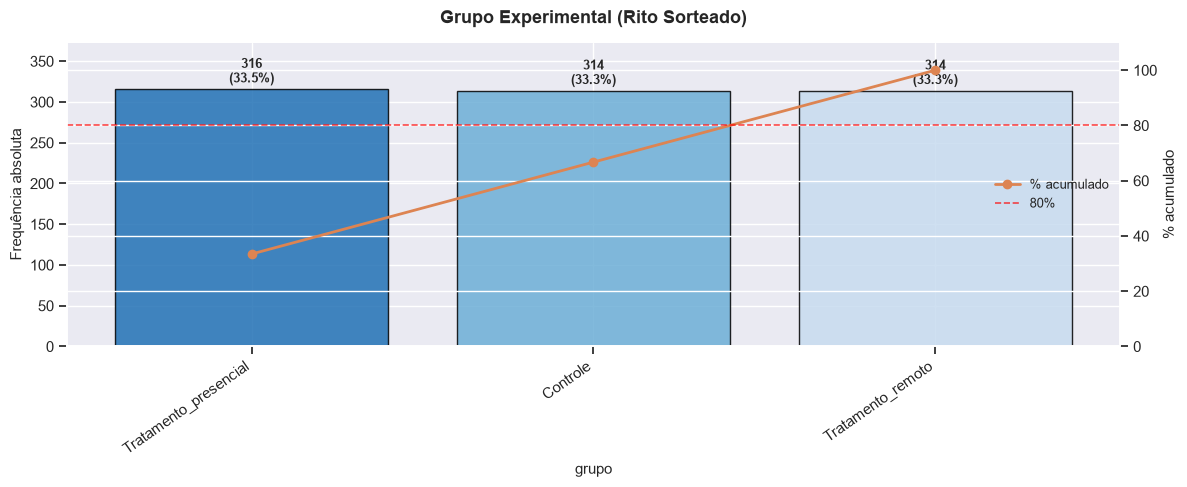

Tabela de frequências — grupo


,Categoria,N,Prop. (%),% Acumulado
0,Tratamento_presencial,316,33.47,33.47
1,Controle,314,33.26,66.74
2,Tratamento_remoto,314,33.26,100.00


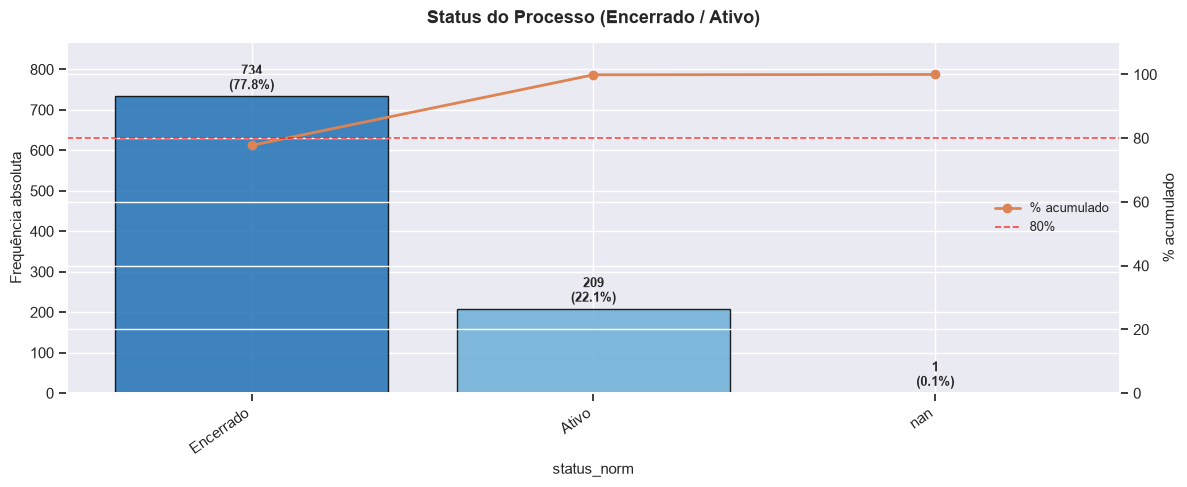

Tabela de frequências — status_norm


,Categoria,N,Prop. (%),% Acumulado
0,Encerrado,734,77.75,77.75
1,Ativo,209,22.14,99.89
2,NaN,1,0.11,100.00


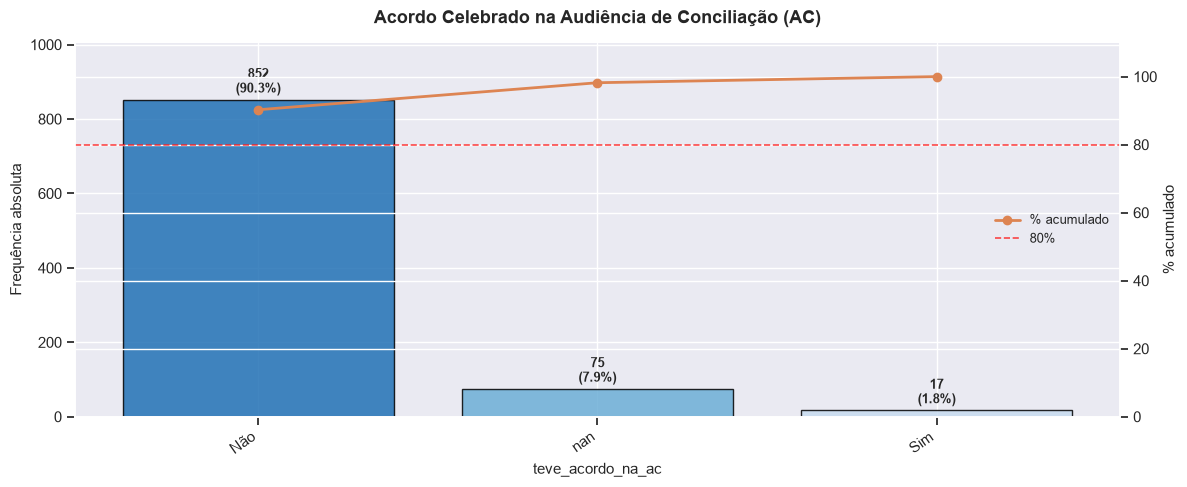

Tabela de frequências — teve_acordo_na_ac


,Categoria,N,Prop. (%),% Acumulado
0,Não,852,90.25,90.25
1,NaN,75,7.94,98.20
2,Sim,17,1.80,100.00


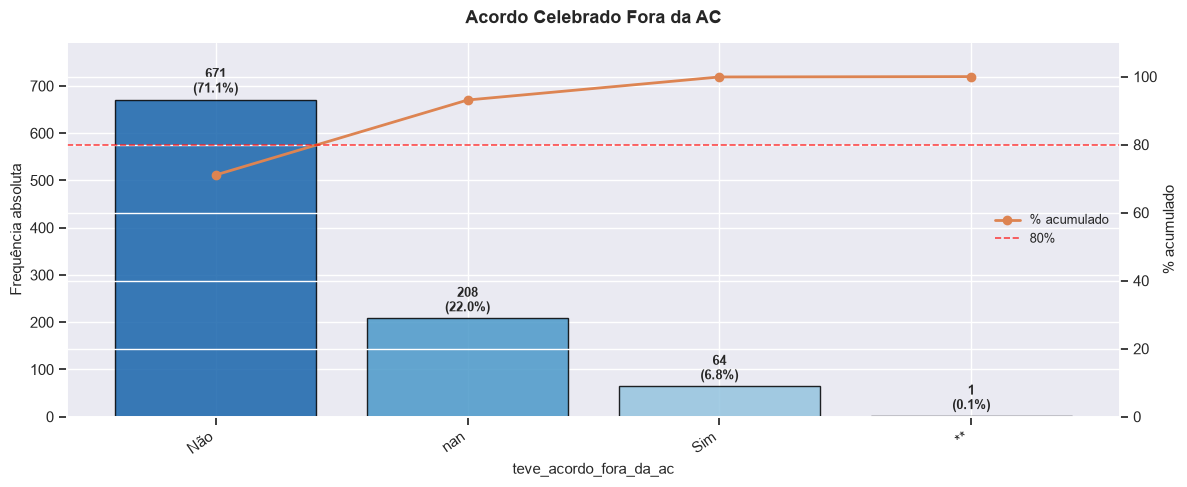

Tabela de frequências — teve_acordo_fora_da_ac


,Categoria,N,Prop. (%),% Acumulado
0,Não,671,71.08,71.08
1,NaN,208,22.03,93.11
2,Sim,64,6.78,99.89
3,**,1,0.11,100.00


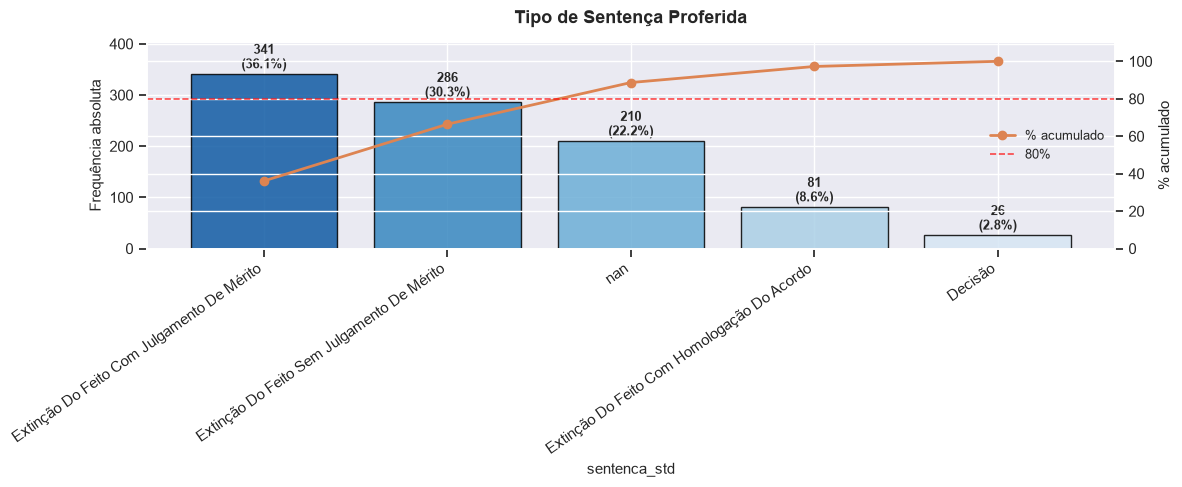

Tabela de frequências — sentenca_std


,Categoria,N,Prop. (%),% Acumulado
0,Extinção Do Feito Com Julgamento De Mérito,341,36.12,36.12
1,Extinção Do Feito Sem Julgamento De Mérito,286,30.30,66.42
2,NaN,210,22.25,88.67
3,Extinção Do Feito Com Homologação Do Acordo,81,8.58,97.25
4,Decisão,26,2.75,100.00


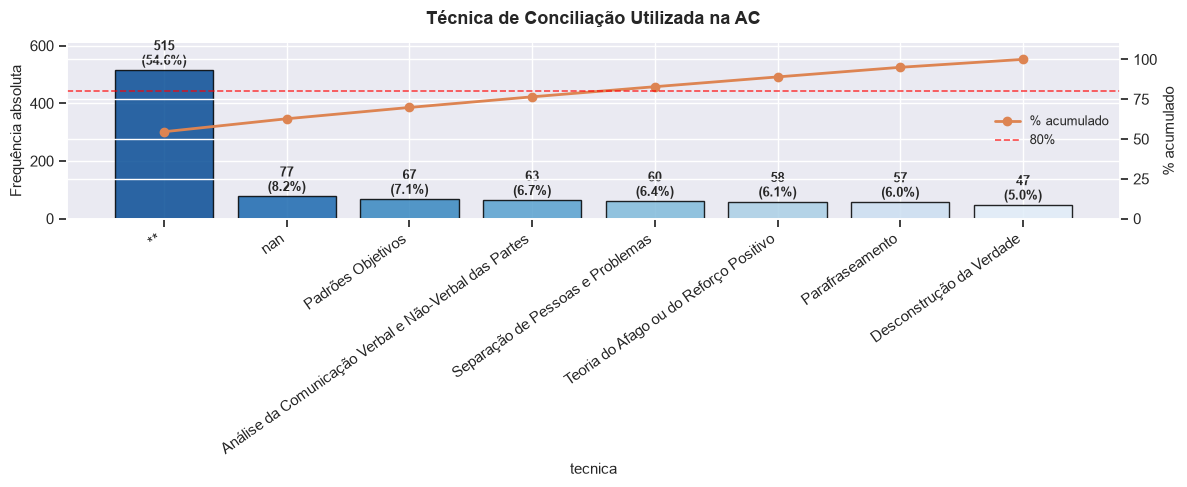

Tabela de frequências — tecnica


,Categoria,N,Prop. (%),% Acumulado
0,**,515,54.56,54.56
1,NaN,77,8.16,62.71
2,Padrões Objetivos,67,7.10,69.81
3,Análise da Comunicação Verbal e Não-Verbal das...,63,6.67,76.48
4,Separação de Pessoas e Problemas,60,6.36,82.84
5,Teoria do Afago ou do Reforço Positivo,58,6.14,88.98
6,Parafraseamento,57,6.04,95.02
7,Desconstrução da Verdade,47,4.98,100.00


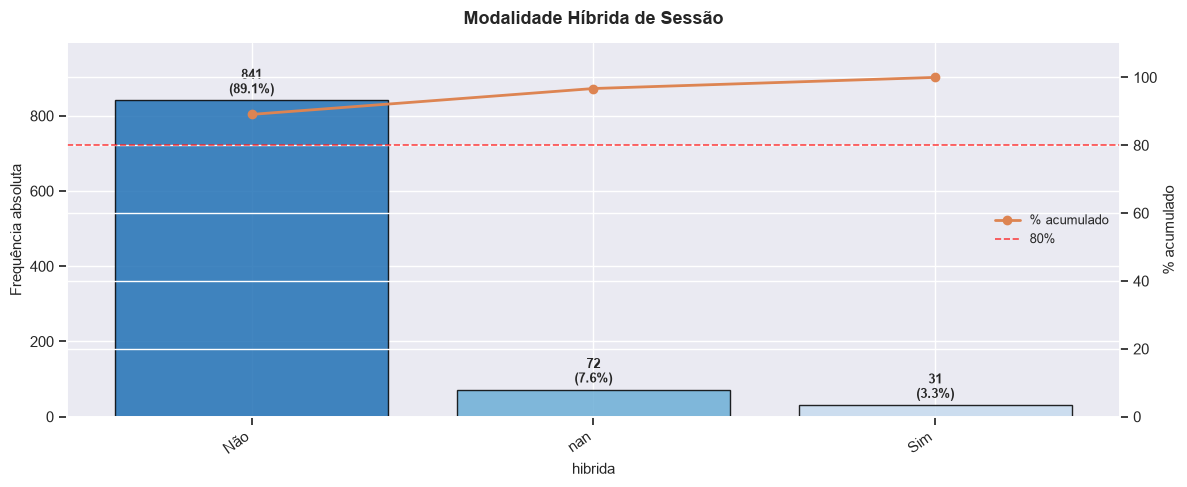

Tabela de frequências — hibrida


,Categoria,N,Prop. (%),% Acumulado
0,Não,841,89.09,89.09
1,NaN,72,7.63,96.72
2,Sim,31,3.28,100.00


In [12]:
# ── Gráficos para todas as variáveis categóricas de interesse ─────────────

# Dicionário: variável → título descritivo
VARS_CAT = {
    'grupo'                 : 'Grupo Experimental (Rito Sorteado)',
    'status_norm'           : 'Status do Processo (Encerrado / Ativo)',
    'teve_acordo_na_ac'     : 'Acordo Celebrado na Audiência de Conciliação (AC)',
    'teve_acordo_fora_da_ac': 'Acordo Celebrado Fora da AC',
    'sentenca_std'          : 'Tipo de Sentença Proferida',
    'tecnica'               : 'Técnica de Conciliação Utilizada na AC',
    'hibrida'               : 'Modalidade Híbrida de Sessão',
}

for var, titulo in VARS_CAT.items():
    if var in dados.columns:
        print(f'\n{"="*70}')
        plot_barras_pareto(dados, var, titulo=titulo)

## 12. Análise de Variáveis Quantitativas

**Objetivo (Exercício 2 do pipeline-modelo):** criar dot plot, histograma com KDE e boxplot para cada variável de duração, sempre indicando a unidade de medida (dias).

**Variáveis analisadas:**
| Variável | Descrição |
|---|---|
| `duracao_sent2` | Dias entre distribuição e sentença (método 2 de cálculo) |
| `duracao_tecn` | Duração para processos com técnica de conciliação registrada |
| `duracao_sort` | Duração contada a partir do sorteio do rito |
| `duracao_proc` | **Variável-alvo principal** — duração total do processo |

> **Como interpretar:** a distribuição é simétrica ou assimétrica? Existem outliers? Média e mediana são próximas?

In [13]:
# ── Função auxiliar: análise completa de variável quantitativa ─────────────

def analise_quantitativa(df: pd.DataFrame, variavel: str,
                          unidade: str = 'dias', bins: int = 25) -> None:
    """
    Gera dot plot, histograma + KDE e boxplot para uma variável quantitativa.

    Parâmetros
    ----------
    df       : DataFrame de entrada.
    variavel : Nome da variável quantitativa.
    unidade  : Unidade de medida para os eixos.
    bins     : Número de intervalos do histograma.
    """
    serie = df[variavel].dropna()
    xlabel = f'{variavel} ({unidade})'

    # Estatísticas descritivas
    desc = {
        'N (obs.)'      : len(serie),
        'Média'         : serie.mean(),
        'Mediana'       : serie.median(),
        'D.Padrão'      : serie.std(),
        'Mín'           : serie.min(),
        'Q1 (25%)'      : serie.quantile(.25),
        'Q3 (75%)'      : serie.quantile(.75),
        'P90'           : serie.quantile(.90),
        'Máx'           : serie.max(),
        'IQR'           : serie.quantile(.75) - serie.quantile(.25),
        'Assimetria'    : serie.skew(),
        'Curtose'       : serie.kurtosis(),
    }

    fig, axes = plt.subplots(3, 1, figsize=(12, 14))
    fig.suptitle(f'Análise de {variavel}', fontsize=14, fontweight='bold')

    # 1) Dot plot
    axes[0].scatter(serie.values, np.ones(len(serie)), alpha=0.3, s=18,
                    color='steelblue', edgecolors='none')
    axes[0].axvline(serie.mean(),   color='red',   linestyle='--', linewidth=1.5,
                    label=f'Média = {serie.mean():.1f}')
    axes[0].axvline(serie.median(), color='green', linestyle='--', linewidth=1.5,
                    label=f'Mediana = {serie.median():.1f}')
    axes[0].set_yticks([])
    axes[0].set_xlabel(xlabel, fontsize=10)
    axes[0].set_title('Dot Plot', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=9)
    for sp in ['left', 'top', 'right']:
        axes[0].spines[sp].set_visible(False)

    # 2) Histograma + KDE
    axes[1].hist(serie, bins=bins, color='steelblue', edgecolor='white', alpha=0.75)
    ax1b = axes[1].twinx()
    sns.kdeplot(serie, ax=ax1b, color='navy', linewidth=2)
    ax1b.set_ylabel('Densidade', fontsize=9)
    axes[1].axvline(serie.mean(),   color='red',   linestyle='--', linewidth=1.5,
                    label=f'Média = {serie.mean():.1f}')
    axes[1].axvline(serie.median(), color='green', linestyle='--', linewidth=1.5,
                    label=f'Mediana = {serie.median():.1f}')
    axes[1].set_xlabel(xlabel, fontsize=10)
    axes[1].set_ylabel('Frequência', fontsize=10)
    axes[1].set_title('Histograma + KDE', fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].spines['top'].set_visible(False)

    # 3) Boxplot horizontal
    bp = axes[2].boxplot(serie, vert=False, patch_artist=True,
                         boxprops=dict(facecolor='lightsteelblue', alpha=0.8),
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='tomato',
                                         markersize=5, alpha=0.5),
                         whiskerprops=dict(color='navy'),
                         capprops=dict(color='navy'))
    # Losango vermelho na posição da média
    axes[2].plot(serie.mean(), 1, marker='D', color='red', markersize=9,
                 markeredgecolor='darkred', markeredgewidth=1.2, zorder=5,
                 label=f'Média = {serie.mean():.1f}')
    axes[2].set_xlabel(xlabel, fontsize=10)
    axes[2].set_title('Boxplot', fontsize=11, fontweight='bold')
    axes[2].set_yticklabels([''])
    axes[2].legend(fontsize=9)
    axes[2].spines['top'].set_visible(False)
    axes[2].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Estatísticas descritivas
    print(f'\nEstatísticas descritivas — {variavel}')
    print('=' * 55)
    for k, v in desc.items():
        fmt = f'{int(v):>10d}' if k == 'N (obs.)' else f'{v:>12.2f} {unidade}'
        print(f'  {k:20s}: {fmt}')
    print()

print('Função analise_quantitativa() definida.')

Função analise_quantitativa() definida.



Duração até sentença — cálculo 2


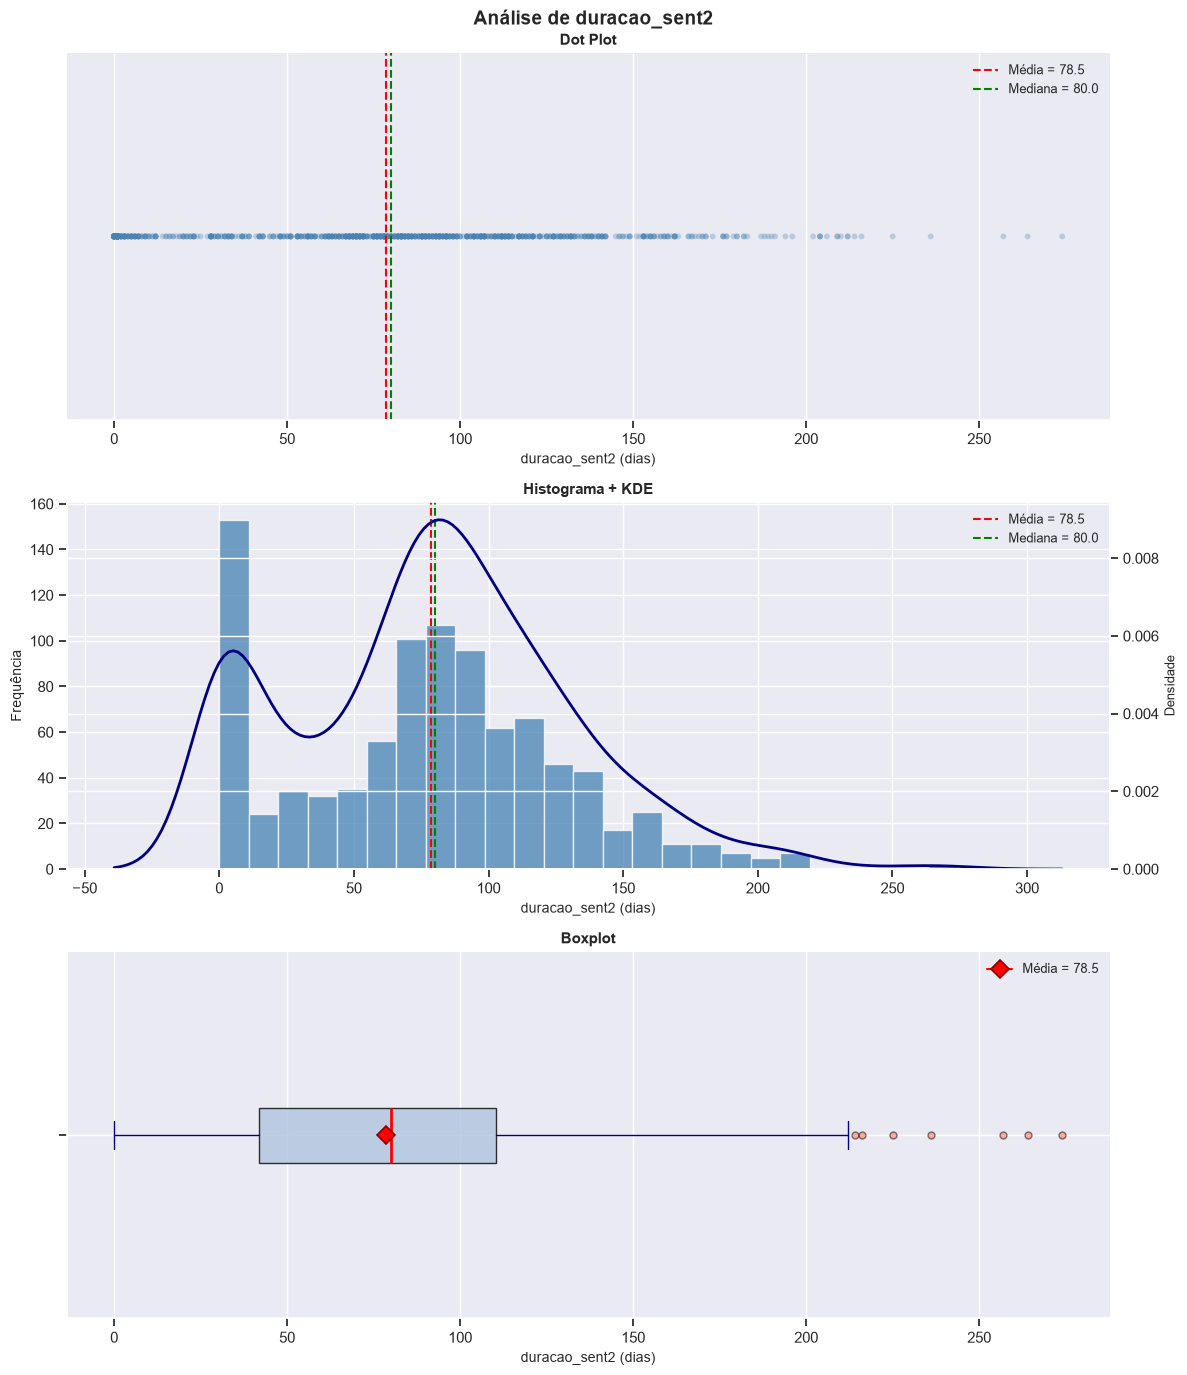


Estatísticas descritivas — duracao_sent2
  N (obs.)            :        943
  Média               :        78.46 dias
  Mediana             :        80.00 dias
  D.Padrão            :        51.21 dias
  Mín                 :         0.00 dias
  Q1 (25%)            :        42.00 dias
  Q3 (75%)            :       110.50 dias
  P90                 :       141.00 dias
  Máx                 :       274.00 dias
  IQR                 :        68.50 dias
  Assimetria          :         0.30 dias
  Curtose             :         0.01 dias


Duração (processos com técnica de conciliação)


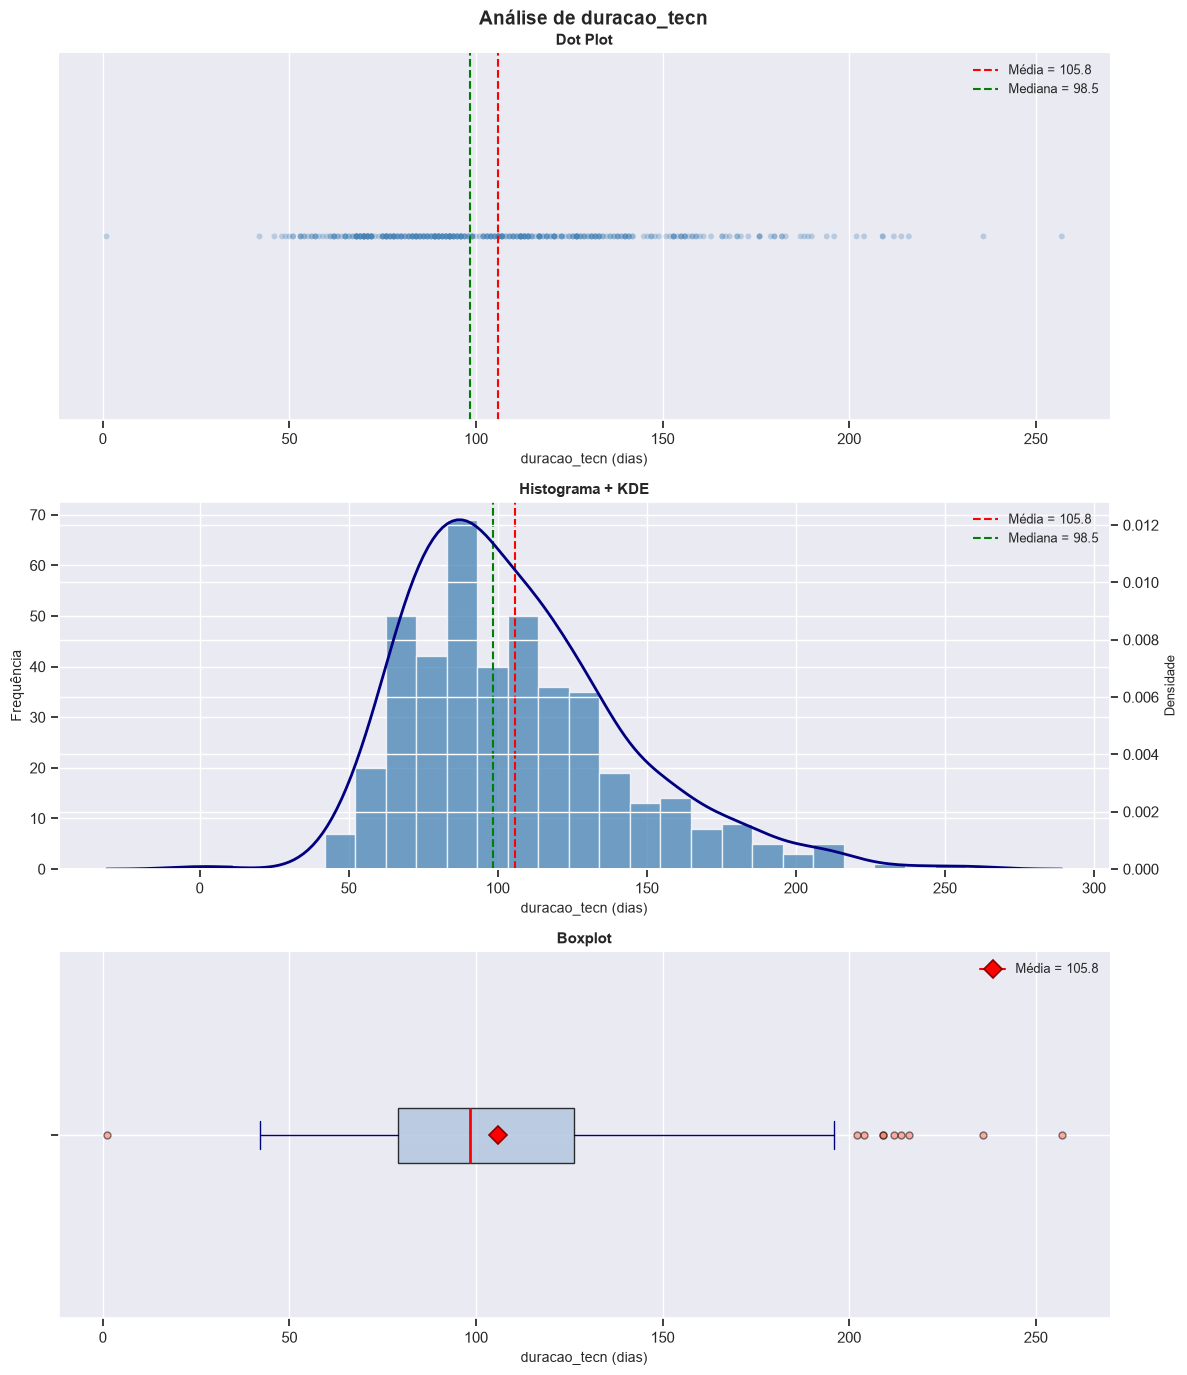


Estatísticas descritivas — duracao_tecn
  N (obs.)            :        428
  Média               :       105.81 dias
  Mediana             :        98.50 dias
  D.Padrão            :        36.11 dias
  Mín                 :         1.00 dias
  Q1 (25%)            :        79.00 dias
  Q3 (75%)            :       126.25 dias
  P90                 :       155.30 dias
  Máx                 :       257.00 dias
  IQR                 :        47.25 dias
  Assimetria          :         0.92 dias
  Curtose             :         1.12 dias


Duração a partir do sorteio do rito


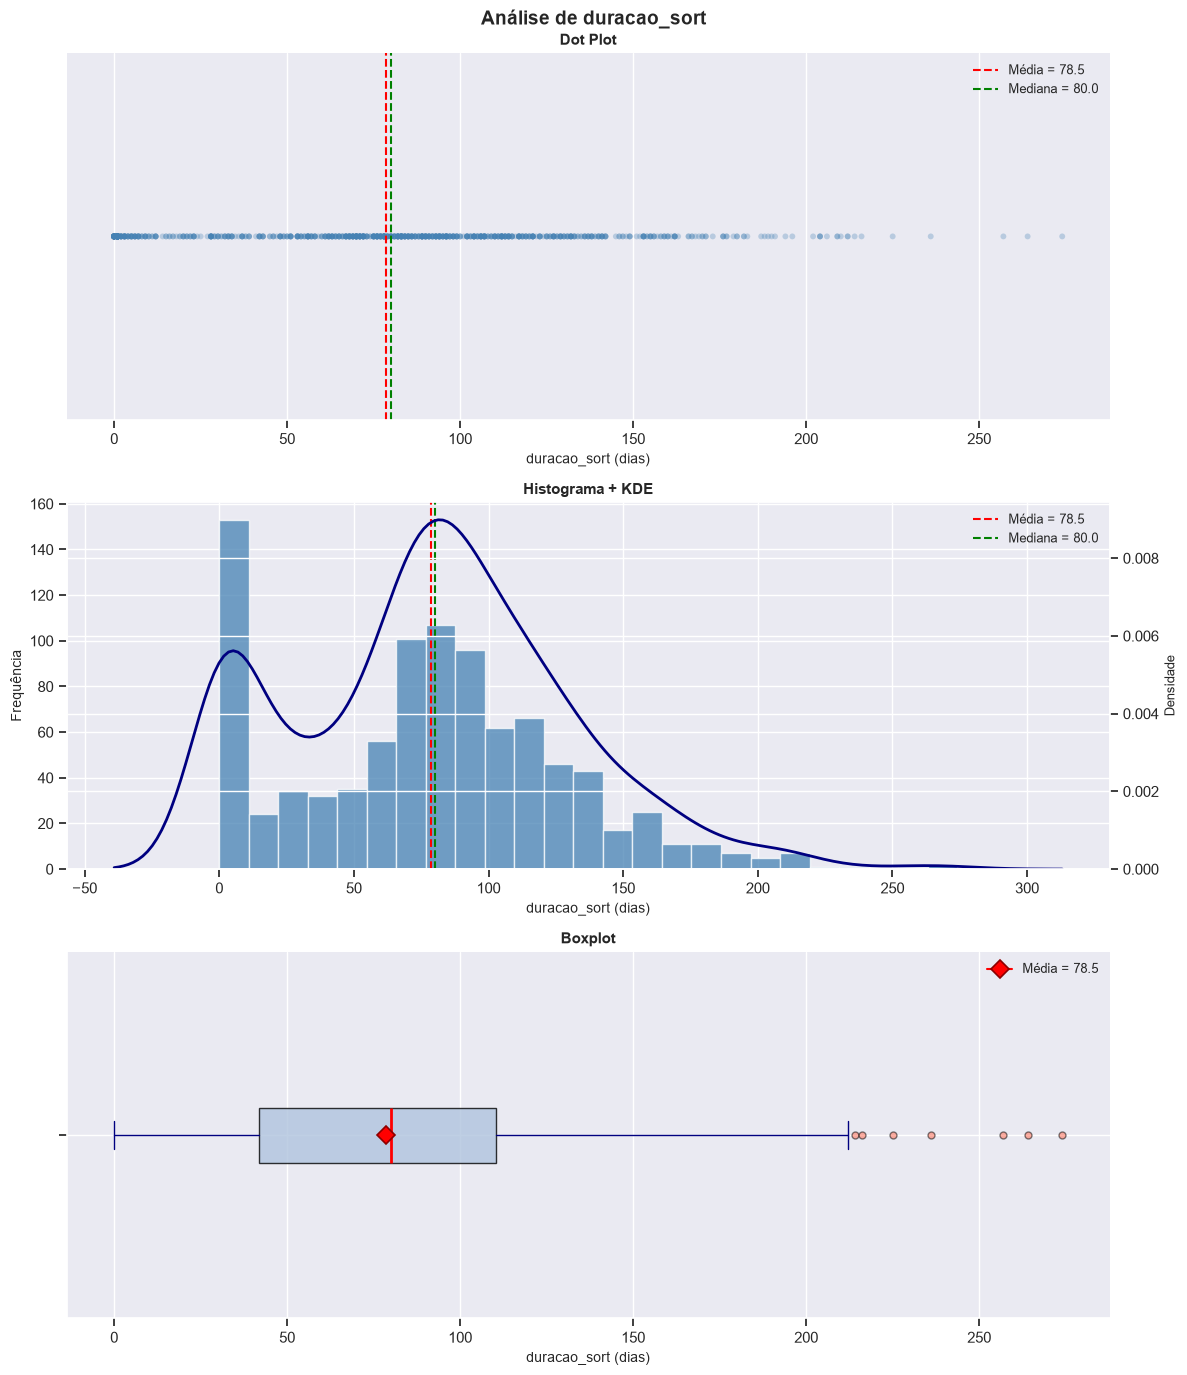


Estatísticas descritivas — duracao_sort
  N (obs.)            :        943
  Média               :        78.46 dias
  Mediana             :        80.00 dias
  D.Padrão            :        51.21 dias
  Mín                 :         0.00 dias
  Q1 (25%)            :        42.00 dias
  Q3 (75%)            :       110.50 dias
  P90                 :       141.00 dias
  Máx                 :       274.00 dias
  IQR                 :        68.50 dias
  Assimetria          :         0.30 dias
  Curtose             :         0.01 dias


Duração total do processo (variável-alvo)


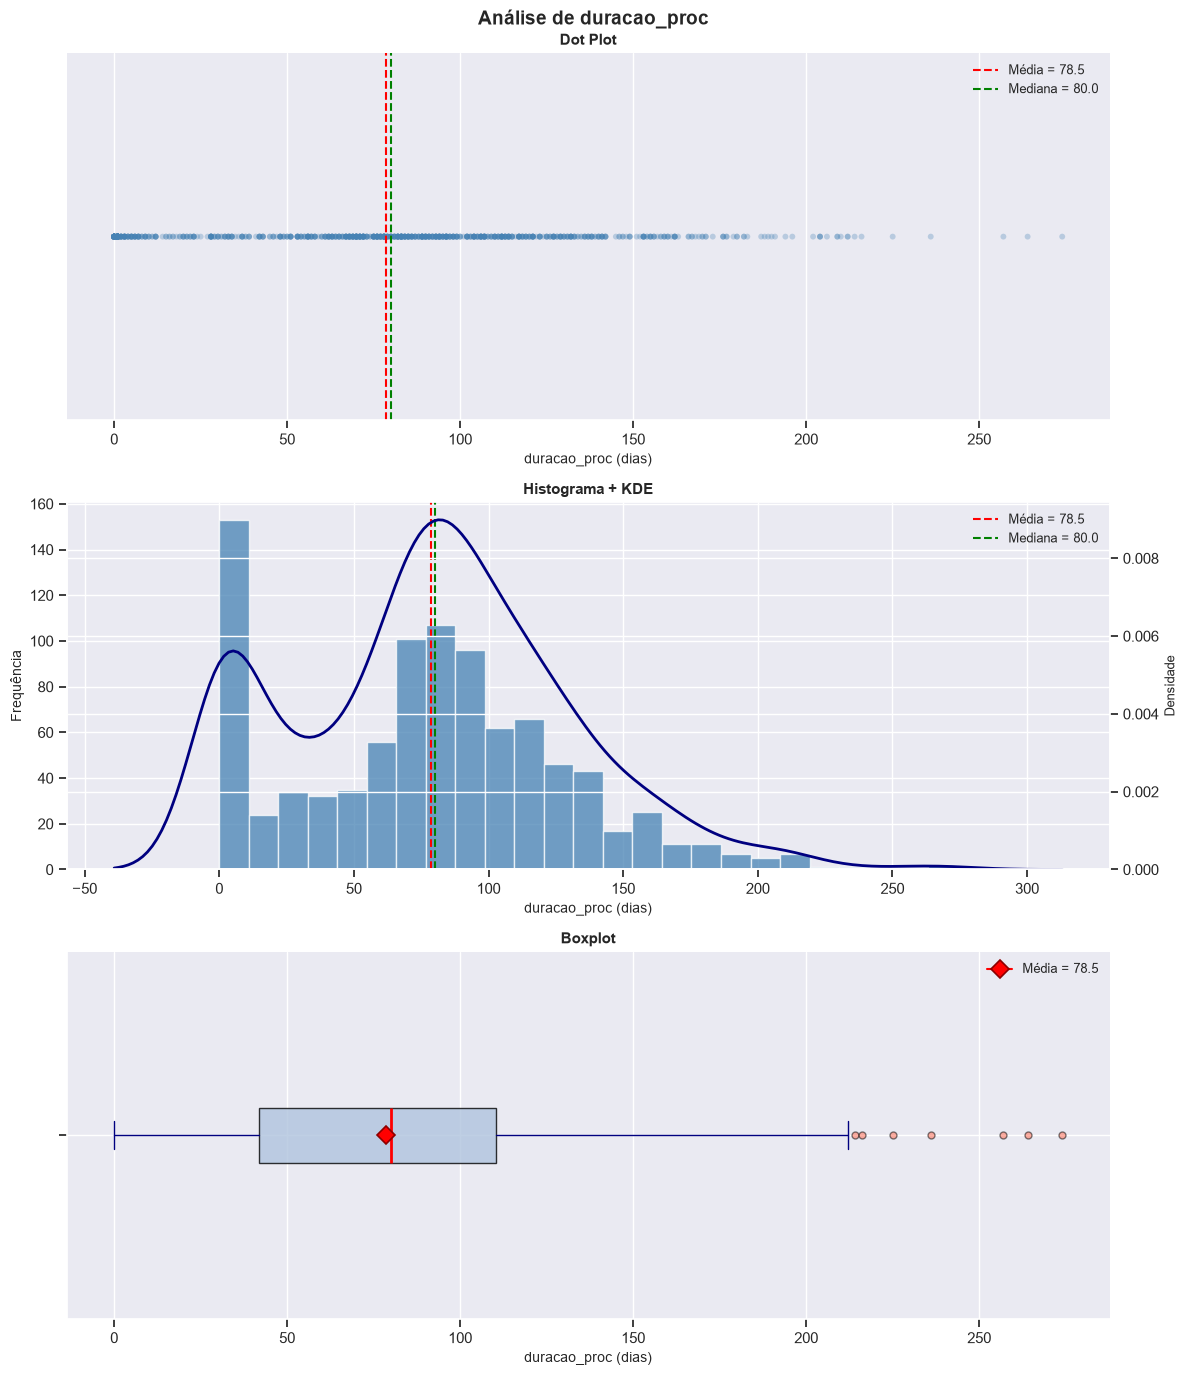


Estatísticas descritivas — duracao_proc
  N (obs.)            :        943
  Média               :        78.46 dias
  Mediana             :        80.00 dias
  D.Padrão            :        51.21 dias
  Mín                 :         0.00 dias
  Q1 (25%)            :        42.00 dias
  Q3 (75%)            :       110.50 dias
  P90                 :       141.00 dias
  Máx                 :       274.00 dias
  IQR                 :        68.50 dias
  Assimetria          :         0.30 dias
  Curtose             :         0.01 dias



In [14]:
# ── Aplicar análise individual para cada variável de duração ──────────────

VARS_QUANT = {
    'duracao_sent2': 'Duração até sentença — cálculo 2',
    'duracao_tecn' : 'Duração (processos com técnica de conciliação)',
    'duracao_sort' : 'Duração a partir do sorteio do rito',
    'duracao_proc' : 'Duração total do processo (variável-alvo)',
}

for var, descricao in VARS_QUANT.items():
    if var in dados.columns:
        print(f'\n{"="*70}')
        print(descricao)
        analise_quantitativa(dados, var, unidade='dias')

## 13. Comparação do Tempo de Tramitação por Grupo Experimental

**Objetivo (Exercício 3 do pipeline-modelo):** comparar a distribuição da variável `duracao_proc` entre os três grupos experimentais usando boxplots e histogramas, e aplicar o **teste de Kruskal-Wallis** para verificar se as medianas diferem estatisticamente.

**Hipóteses (Kruskal-Wallis):**
- **H₀:** as medianas de `duracao_proc` são iguais nos três grupos (Controle, Tratamento_presencial, Tratamento_remoto).
- **H₁:** pelo menos um grupo apresenta mediana diferente das demais.

> **Como interpretar:** qual grupo tem maior mediana? Qual tem mais variabilidade? Há outliers concentrados em algum grupo?

In [15]:
# ── Função auxiliar: boxplots por grupo (ordenados pela mediana) ───────────

def comparacao_grupos_boxplot(df: pd.DataFrame, var_quant: str, var_cat: str,
                              unidade: str = '', ordenar_mediana: bool = True) -> None:
    """
    Boxplots comparativos de uma variável quantitativa entre grupos categóricos.

    Parâmetros
    ----------
    df             : DataFrame de entrada.
    var_quant      : Variável quantitativa.
    var_cat        : Variável categórica (grupos).
    unidade        : Unidade de medida.
    ordenar_mediana: Se True, ordena grupos pela mediana crescente.
    """
    df_tmp = df[[var_quant, var_cat]].dropna()

    # Ordenar pela mediana de cada grupo
    if ordenar_mediana:
        ordem = (
            df_tmp.groupby(var_cat, observed=True)[var_quant]
            .median()
            .sort_values()
            .index.tolist()
        )
    else:
        ordem = df_tmp[var_cat].cat.categories.tolist() if hasattr(df_tmp[var_cat], 'cat') else df_tmp[var_cat].unique().tolist()

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.boxplot(data=df_tmp, x=var_cat, y=var_quant, order=ordem,
                palette='Blues', ax=ax, width=0.55,
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='tomato', alpha=0.4, markersize=4))
    sns.stripplot(data=df_tmp, x=var_cat, y=var_quant, order=ordem,
                  color='navy', alpha=0.18, size=3, ax=ax)

    # Anotar mediana de cada grupo
    for i, grupo in enumerate(ordem):
        med = df_tmp.loc[df_tmp[var_cat] == grupo, var_quant].median()
        ax.text(i, med + df_tmp[var_quant].max() * 0.02,
                f'Med={med:.0f}', ha='center', va='bottom', fontsize=9, color='red')

    ax.set_xlabel(var_cat, fontsize=11)
    ax.set_ylabel(f'{var_quant} ({unidade})' if unidade else var_quant, fontsize=11)
    ax.set_title(f'{var_quant} por {var_cat}', fontsize=13, fontweight='bold')
    plt.xticks(rotation=20, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    # Estatísticas por grupo
    print(f'Estatísticas de {var_quant} por {var_cat}:')
    display(
        df_tmp.groupby(var_cat, observed=True)[var_quant]
        .describe(percentiles=[.25, .5, .75, .9])
        .round(1)
    )


def comparacao_grupos_histograma(df: pd.DataFrame, var_quant: str, var_cat: str,
                                  unidade: str = '', bins: int = 20) -> None:
    """
    Histogramas em painel vertical (um por grupo) para comparação de distribuições.
    """
    df_tmp = df[[var_quant, var_cat]].dropna()
    grupos = df_tmp[var_cat].unique()
    n = len(grupos)

    fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n), sharex=True)
    if n == 1:
        axes = [axes]

    paleta = sns.color_palette('Set2', n)
    for ax, grupo, cor in zip(axes, grupos, paleta):
        sub = df_tmp.loc[df_tmp[var_cat] == grupo, var_quant]
        ax.hist(sub, bins=bins, color=cor, edgecolor='white', alpha=0.85)
        ax.axvline(sub.mean(),   color='red',   linestyle='--', linewidth=1.5,
                   label=f'Média={sub.mean():.0f}')
        ax.axvline(sub.median(), color='green', linestyle='--', linewidth=1.5,
                   label=f'Med={sub.median():.0f}')
        ax.set_title(str(grupo), fontsize=11, fontweight='bold')
        ax.set_ylabel('Frequência', fontsize=9)
        ax.legend(fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[-1].set_xlabel(f'{var_quant} ({unidade})' if unidade else var_quant, fontsize=11)
    fig.suptitle(f'Distribuição de {var_quant} por {var_cat}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Funções de comparação por grupos definidas.')

Funções de comparação por grupos definidas.


BOXPLOTS: duracao_proc por grupo experimental


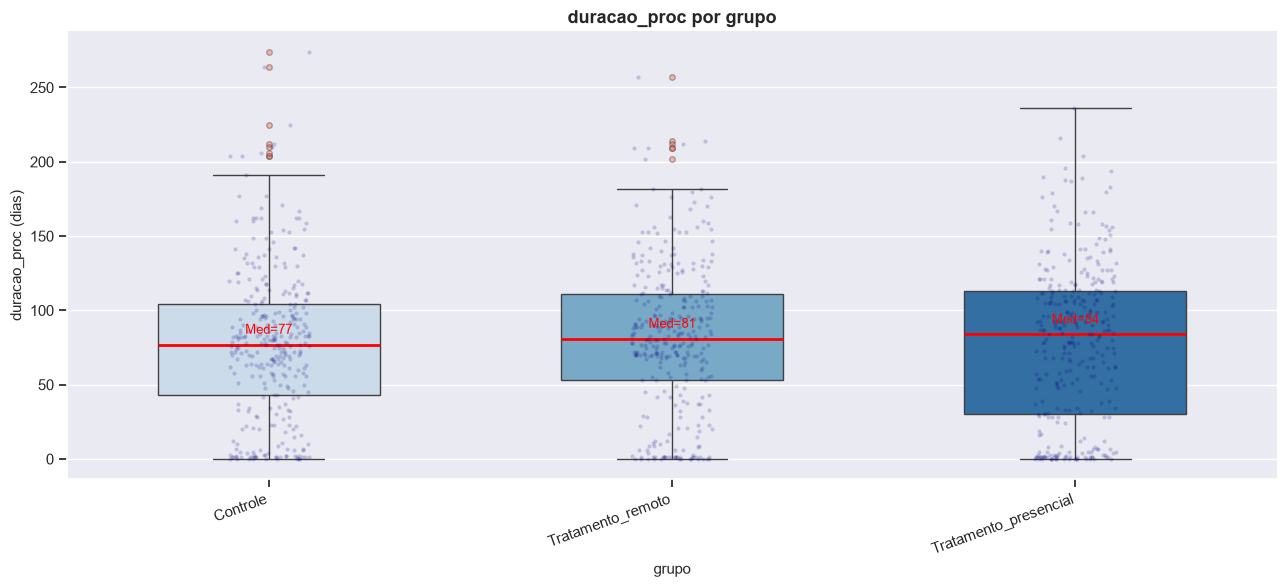

Estatísticas de duracao_proc por grupo:


,count,mean,std,min,25%,50%,75%,90%,max
grupo,,,,,,,,,
Controle,314.00,77.00,51.00,0.00,43.00,77.00,104.00,141.00,274.00
Tratamento_presencial,315.00,77.50,53.10,0.00,30.50,84.00,113.00,140.60,236.00
Tratamento_remoto,314.00,80.90,49.50,0.00,53.00,81.00,110.80,141.40,257.00


HISTOGRAMAS: duracao_proc por grupo experimental


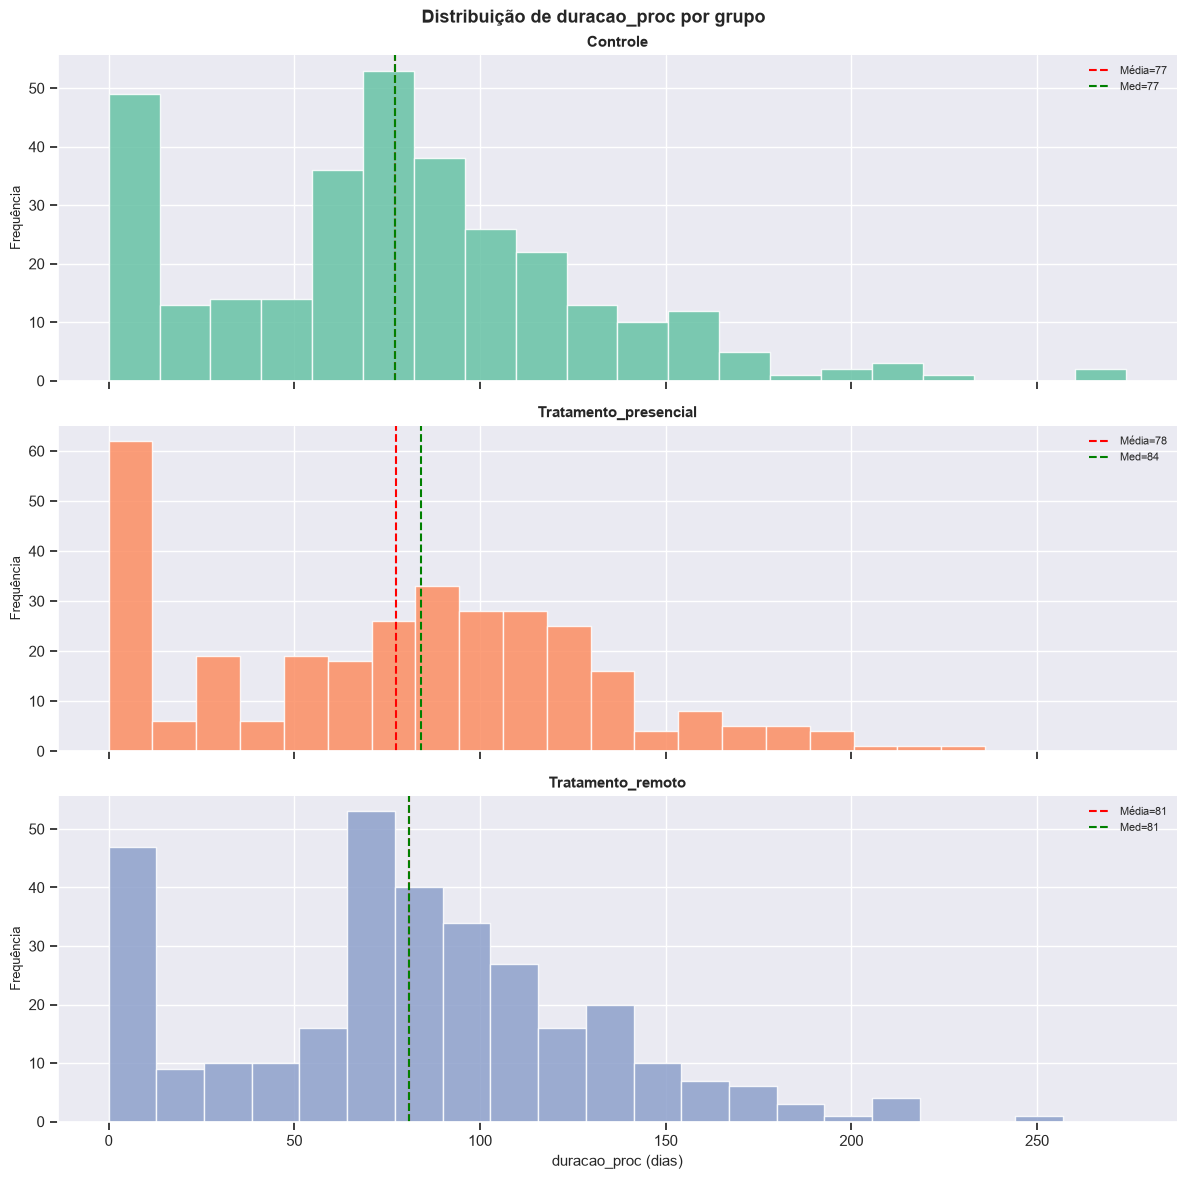


TESTE DE KRUSKAL-WALLIS
  Grupos testados : ['Controle', 'Tratamento_presencial', 'Tratamento_remoto']
  Estatística H   : 1.4772
  p-valor         : 0.4778
  → Conclusão: Não se rejeita H₀ (p ≥ 0,05). Sem evidência de
    diferença significativa entre as medianas dos grupos.


In [16]:
# ── Comparação entre grupos experimentais ────────────────────────────────

if {'grupo', 'duracao_proc'}.issubset(dados.columns):

    # Boxplots
    print('BOXPLOTS: duracao_proc por grupo experimental')
    comparacao_grupos_boxplot(dados, 'duracao_proc', 'grupo', unidade='dias')

    # Histogramas
    print('HISTOGRAMAS: duracao_proc por grupo experimental')
    comparacao_grupos_histograma(dados, 'duracao_proc', 'grupo', unidade='dias')

    # ── Teste de Kruskal-Wallis ────────────────────────────────────────────
    grupos_dados = [
        g['duracao_proc'].dropna().values
        for _, g in dados.dropna(subset=['grupo']).groupby('grupo', observed=True)
    ]
    nomes_grupos = [
        k for k, _ in dados.dropna(subset=['grupo']).groupby('grupo', observed=True)
    ]

    H, p_kw = stats.kruskal(*grupos_dados)
    print('\nTESTE DE KRUSKAL-WALLIS')
    print('=' * 55)
    print(f'  Grupos testados : {nomes_grupos}')
    print(f'  Estatística H   : {H:.4f}')
    print(f'  p-valor         : {p_kw:.4g}')
    if p_kw < 0.05:
        print('  → Conclusão: Rejeita-se H₀ (p < 0,05). Há diferença significativa')
        print('    entre as medianas de pelo menos um par de grupos.')
    else:
        print('  → Conclusão: Não se rejeita H₀ (p ≥ 0,05). Sem evidência de')
        print('    diferença significativa entre as medianas dos grupos.')

    # ── Testes post-hoc (Mann-Whitney por par) ────────────────────────────
    if p_kw < 0.05:
        print('\nTestes post-hoc (Mann-Whitney, dois a dois):')
        print('-' * 55)
        from itertools import combinations
        for (n1, g1), (n2, g2) in combinations(zip(nomes_grupos, grupos_dados), 2):
            U, p_mw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
            sig = '* sig.' if p_mw < 0.05 else 'n.s.'
            print(f'  {n1} vs {n2}: U={U:.1f}, p={p_mw:.4g}  {sig}')

BOXPLOTS: duracao_proc por status do processo


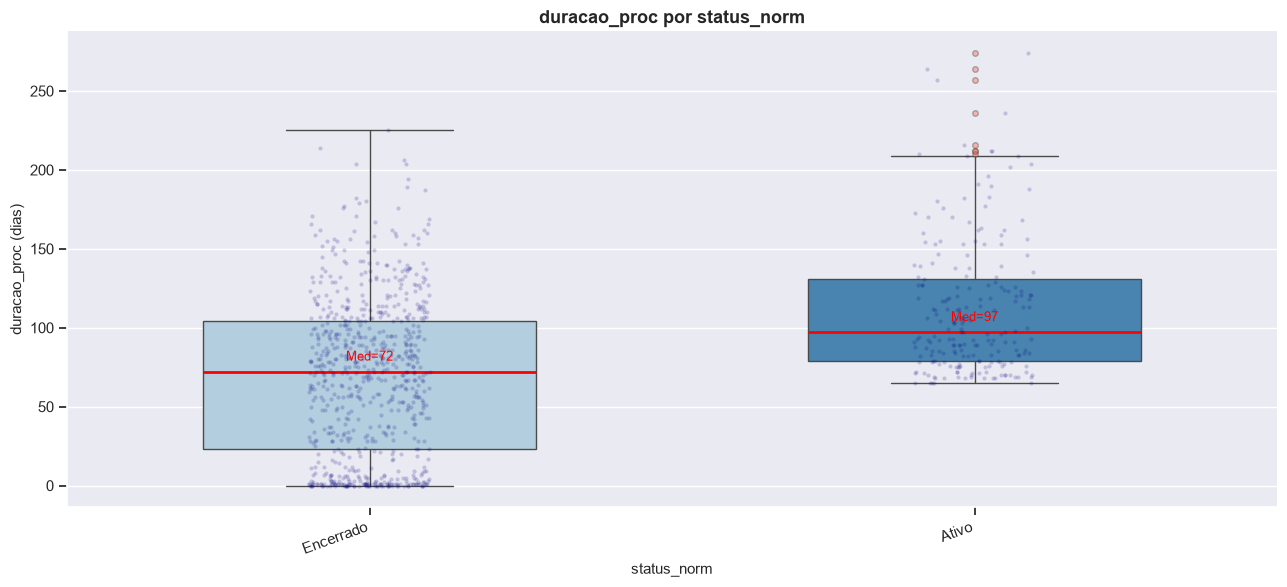

Estatísticas de duracao_proc por status_norm:


,count,mean,std,min,25%,50%,75%,90%,max
status_norm,,,,,,,,,
Ativo,209.00,112.20,42.90,65.00,79.00,97.00,131.00,173.60,274.00
Encerrado,734.00,68.90,49.30,0.00,23.00,72.00,104.00,132.70,225.00



TESTE DE MANN-WHITNEY — Encerrado vs. Ativo
  H₀: medianas de duracao_proc iguais entre Encerrado e Ativo.
  H₁: medianas diferentes.
  U = 41437.50  |  p-valor = 3.209e-24
  → Rejeita-se H₀ (α = 0,05)


In [17]:
# ── Comparação entre processos Encerrados vs. Ativos ──────────────────────

if {'status_norm', 'duracao_proc'}.issubset(dados.columns):

    print('BOXPLOTS: duracao_proc por status do processo')
    comparacao_grupos_boxplot(dados, 'duracao_proc', 'status_norm', unidade='dias')

    a = dados.loc[dados['status_norm'] == 'Encerrado', 'duracao_proc'].dropna()
    b = dados.loc[dados['status_norm'] == 'Ativo',     'duracao_proc'].dropna()

    U, p_mw = stats.mannwhitneyu(a, b, alternative='two-sided')
    print('\nTESTE DE MANN-WHITNEY — Encerrado vs. Ativo')
    print('=' * 55)
    print(f'  H₀: medianas de duracao_proc iguais entre Encerrado e Ativo.')
    print(f'  H₁: medianas diferentes.')
    print(f'  U = {U:.2f}  |  p-valor = {p_mw:.4g}')
    conclusao = 'Rejeita-se H₀' if p_mw < 0.05 else 'Não se rejeita H₀'
    print(f'  → {conclusao} (α = 0,05)')

## 14. Associação entre Variáveis Categóricas

**Objetivo (Exercício 4 do pipeline-modelo):** explorar associações entre pares de variáveis categóricas com tabela de contingência, gráfico mosaico (quando disponível) e **teste qui-quadrado** de independência.

**Pares analisados:**
1. `grupo` × `status_norm` — o grupo experimental influencia o encerramento?
2. `grupo` × `teve_acordo_na_ac` — a conciliação obrigatória gera mais acordos?
3. `sentenca_std` × `grupo` — o tipo de sentença difere por grupo?

**Hipóteses (qui-quadrado):**
- **H₀:** as variáveis são independentes.
- **H₁:** existe associação entre as variáveis.

> **Como interpretar:** o gráfico mosaico mostra padrões que desviam do esperado sob independência? O p-valor indica associação significativa?

In [18]:
# ── Função auxiliar: análise de associação entre categóricas ──────────────

def analise_associacao(df: pd.DataFrame, var1: str, var2: str) -> None:
    """
    Tabela de contingência, proporções condicionais, qui-quadrado e mosaico.

    Parâmetros
    ----------
    df   : DataFrame de entrada.
    var1 : Primeira variável categórica (linhas).
    var2 : Segunda variável categórica (colunas).
    """
    df_tmp = df[[var1, var2]].dropna()

    # Tabela de contingência
    tab_abs  = pd.crosstab(df_tmp[var1], df_tmp[var2], margins=True)
    tab_prop = pd.crosstab(df_tmp[var1], df_tmp[var2], normalize='index') * 100

    print(f'\nTabela de contingência: {var1} × {var2}')
    print('=' * 70)
    display(tab_abs)

    print(f'\nProporções por linha (%) — {var1} → {var2}:')
    display(tab_prop.round(1))

    # Qui-quadrado
    tab_raw = pd.crosstab(df_tmp[var1], df_tmp[var2])
    chi2, p, gl, _ = stats.chi2_contingency(tab_raw)

    print(f'\nTeste Qui-Quadrado de Independência')
    print('=' * 70)
    print(f'  H₀: {var1} e {var2} são independentes.')
    print(f'  H₁: existe associação entre {var1} e {var2}.')
    print(f'  χ² = {chi2:.4f}  |  gl = {gl}  |  p-valor = {p:.4g}')
    if p < 0.05:
        print('  → Rejeita-se H₀: há associação significativa (p < 0,05).')
    else:
        print('  → Não se rejeita H₀: sem evidência de associação (p ≥ 0,05).')

    # Mosaico (se statsmodels disponível)
    if mosaic is not None:
        try:
            fig, ax = plt.subplots(figsize=(11, 6))
            mosaic(df_tmp, [var1, var2], ax=ax,
                   title=f'Mosaico: {var1} × {var2}',
                   gap=0.015)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f'  (Mosaico não gerado: {e})')
    else:
        # Alternativa: heatmap da tabela de proporções
        plt.figure(figsize=(9, 4))
        sns.heatmap(tab_prop.round(1), annot=True, fmt='.1f', cmap='Blues')
        plt.title(f'Heatmap de proporções: {var1} × {var2}')
        plt.tight_layout()
        plt.show()

print('Função analise_associacao() definida.')

Função analise_associacao() definida.



Tabela de contingência: grupo × status_norm


status_norm,Ativo,Encerrado,All
grupo,,,
Controle,46,268,314
Tratamento_presencial,74,241,315
Tratamento_remoto,89,225,314
All,209,734,943



Proporções por linha (%) — grupo → status_norm:


status_norm,Ativo,Encerrado
grupo,,
Controle,14.60,85.40
Tratamento_presencial,23.50,76.50
Tratamento_remoto,28.30,71.70



Teste Qui-Quadrado de Independência
  H₀: grupo e status_norm são independentes.
  H₁: existe associação entre grupo e status_norm.
  χ² = 17.5511  |  gl = 2  |  p-valor = 0.0001545
  → Rejeita-se H₀: há associação significativa (p < 0,05).


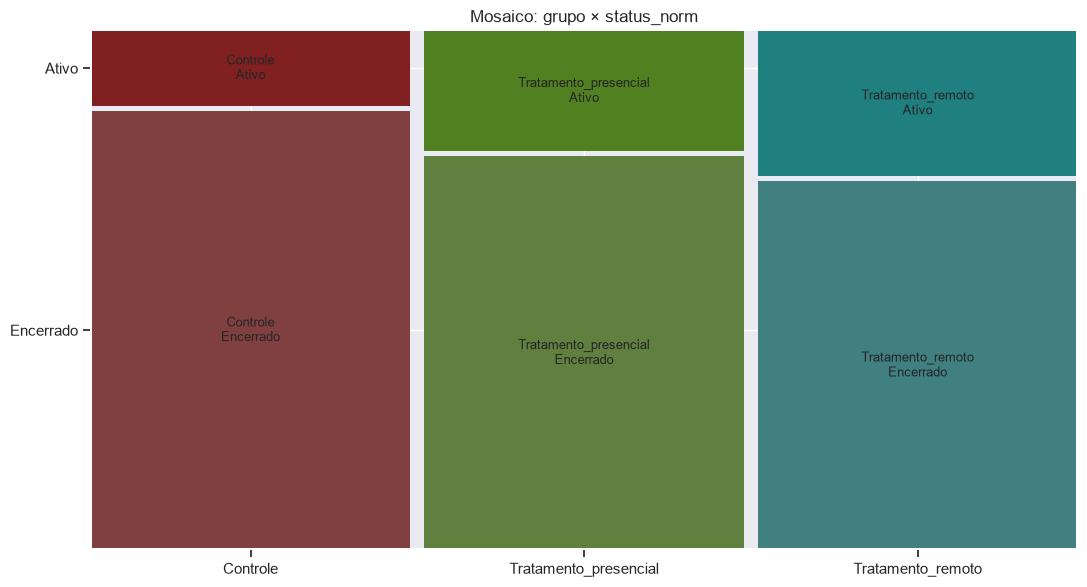

In [19]:
# ── Par 1: grupo × status_norm ────────────────────────────────────────────
# Pergunta: o grupo experimental influencia a probabilidade de encerramento?

if {'grupo', 'status_norm'}.issubset(dados.columns):
    analise_associacao(dados, 'grupo', 'status_norm')


Tabela de contingência: grupo × teve_acordo_na_ac


teve_acordo_na_ac,Não,Sim,All
grupo,,,
Controle,314,0,314
Tratamento_presencial,282,9,291
Tratamento_remoto,256,8,264
All,852,17,869



Proporções por linha (%) — grupo → teve_acordo_na_ac:


teve_acordo_na_ac,Não,Sim
grupo,,
Controle,100.00,0.00
Tratamento_presencial,96.90,3.10
Tratamento_remoto,97.00,3.00



Teste Qui-Quadrado de Independência
  H₀: grupo e teve_acordo_na_ac são independentes.
  H₁: existe associação entre grupo e teve_acordo_na_ac.
  χ² = 9.8127  |  gl = 2  |  p-valor = 0.007399
  → Rejeita-se H₀: há associação significativa (p < 0,05).


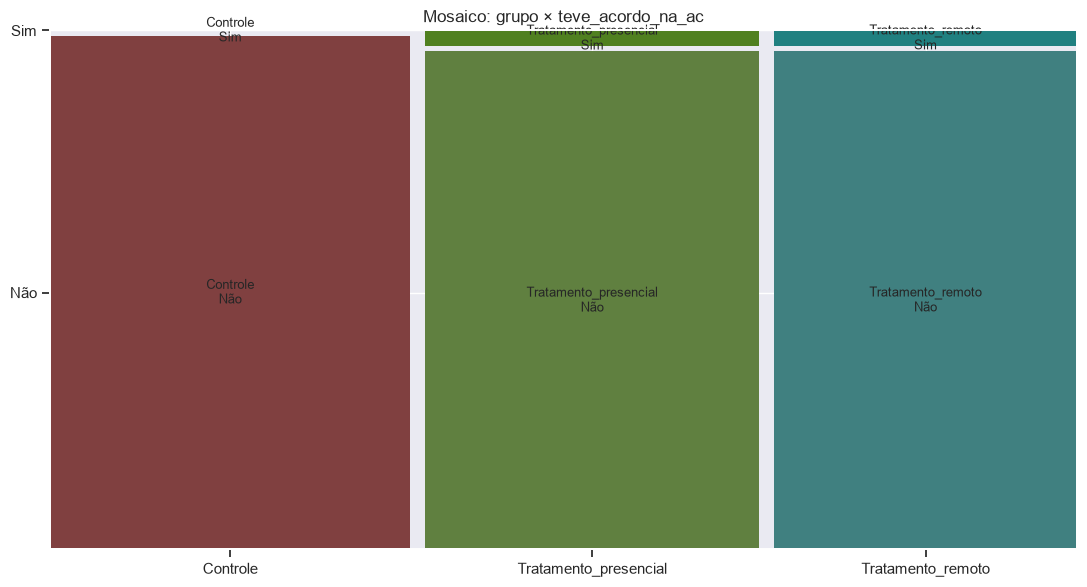

In [20]:
# ── Par 2: grupo × teve_acordo_na_ac ─────────────────────────────────────
# Pergunta: a conciliação obrigatória (presencial ou remota) gera mais acordos?

if {'grupo', 'teve_acordo_na_ac'}.issubset(dados.columns):
    analise_associacao(dados, 'grupo', 'teve_acordo_na_ac')


Tabela de contingência: sentenca_std × grupo


grupo,Controle,Tratamento_presencial,Tratamento_remoto,All
sentenca_std,,,,
Decisão,6,11,9,26
Extinção Do Feito Com Homologação Do Acordo,21,25,35,81
Extinção Do Feito Com Julgamento De Mérito,162,96,83,341
Extinção Do Feito Sem Julgamento De Mérito,79,109,98,286
All,268,241,225,734



Proporções por linha (%) — sentenca_std → grupo:


grupo,Controle,Tratamento_presencial,Tratamento_remoto
sentenca_std,,,
Decisão,23.10,42.30,34.60
Extinção Do Feito Com Homologação Do Acordo,25.90,30.90,43.20
Extinção Do Feito Com Julgamento De Mérito,47.50,28.20,24.30
Extinção Do Feito Sem Julgamento De Mérito,27.60,38.10,34.30



Teste Qui-Quadrado de Independência
  H₀: sentenca_std e grupo são independentes.
  H₁: existe associação entre sentenca_std e grupo.
  χ² = 36.7120  |  gl = 6  |  p-valor = 2.004e-06
  → Rejeita-se H₀: há associação significativa (p < 0,05).


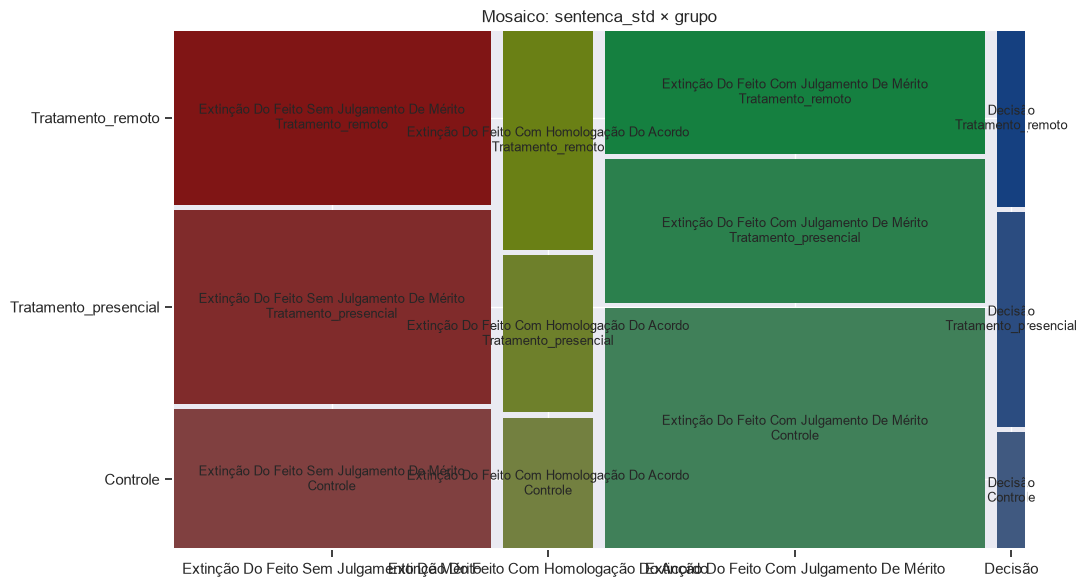

In [21]:
# ── Par 3: sentenca_std × grupo ───────────────────────────────────────────
# Pergunta: o tipo de sentença proferida difere entre os grupos experimentais?

if {'sentenca_std', 'grupo'}.issubset(dados.columns):
    analise_associacao(dados, 'sentenca_std', 'grupo')

## 15. Relações entre Variáveis Quantitativas — Matriz de Correlação e Diagramas de Dispersão

**Objetivo (Exercício 5 do pipeline-modelo):** calcular a **matriz de correlação de Spearman** (preferida por ser robusta a assimetrias), criar um heatmap e analisar pares específicos com diagramas de dispersão e reta de regressão.

> **Importante:** correlação ≠ causalidade. Uma relação estatística não implica causa e efeito.

In [22]:
# ── Função auxiliar: matriz de correlação ─────────────────────────────────

def matriz_correlacao(df: pd.DataFrame, variaveis: list = None,
                       metodo: str = 'spearman') -> pd.DataFrame:
    """
    Calcula e visualiza a matriz de correlação com heatmap anotado.

    Parâmetros
    ----------
    df         : DataFrame de entrada.
    variaveis  : Lista de colunas; se None, usa todas numéricas.
    metodo     : 'pearson' ou 'spearman'.
    """
    df_num = df[variaveis] if variaveis else df.select_dtypes(include='number')
    corr   = df_num.corr(method=metodo)

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, vmin=-1, vmax=1, ax=ax,
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'Matriz de Correlação ({metodo.capitalize()})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Pares com correlação forte (|r| > 0.5)
    print('\nCorrelações mais fortes (|r| > 0,5, excluindo diagonal):')
    print('=' * 60)
    encontrou = False
    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            r = corr.iloc[i, j]
            if abs(r) > 0.5:
                print(f'  {corr.columns[i]:25s} × {corr.columns[j]:25s}: r = {r:.3f}')
                encontrou = True
    if not encontrou:
        print('  (Nenhum par com |r| > 0,5 encontrado)')
    return corr


def analise_dispersao(df: pd.DataFrame, var_x: str, var_y: str,
                       unidade_x: str = '', unidade_y: str = '',
                       cor_grupo: str = None) -> None:
    """
    Diagrama de dispersão com reta de regressão e coeficientes de correlação.

    Parâmetros
    ----------
    df         : DataFrame.
    var_x      : Variável no eixo x.
    var_y      : Variável no eixo y.
    unidade_x  : Unidade de medida de x.
    unidade_y  : Unidade de medida de y.
    cor_grupo  : Coluna categórica para colorir pontos por grupo (opcional).
    """
    cols = [var_x, var_y] + ([cor_grupo] if cor_grupo else [])
    df_tmp = df[cols].dropna()

    r_pear = df_tmp[var_x].corr(df_tmp[var_y], method='pearson')
    r_spea = df_tmp[var_x].corr(df_tmp[var_y], method='spearman')
    slope, intercept, r_val, p_val, _ = stats.linregress(df_tmp[var_x], df_tmp[var_y])

    fig, ax = plt.subplots(figsize=(12, 6))

    if cor_grupo and cor_grupo in df_tmp.columns:
        grupos = df_tmp[cor_grupo].unique()
        paleta = sns.color_palette('Set2', len(grupos))
        for grupo, cor in zip(grupos, paleta):
            sub = df_tmp[df_tmp[cor_grupo] == grupo]
            ax.scatter(sub[var_x], sub[var_y], alpha=0.5, s=40,
                       color=cor, label=str(grupo), edgecolors='none')
        ax.legend(title=cor_grupo, fontsize=9)
    else:
        ax.scatter(df_tmp[var_x], df_tmp[var_y], alpha=0.4, s=40,
                   color='steelblue', edgecolors='none')

    # Reta de regressão
    x_line = np.linspace(df_tmp[var_x].min(), df_tmp[var_x].max(), 200)
    ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2,
            label=f'Reta: y = {slope:.4f}x + {intercept:.2f}')
    ax.legend(fontsize=9)

    # Caixa de informação
    info = (f'Pearson r = {r_pear:.3f}\n'
            f'Spearman ρ = {r_spea:.3f}\n'
            f'R² = {r_val**2:.3f}\n'
            f'p-valor = {p_val:.4g}')
    ax.text(0.04, 0.96, info, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    xlabel = f'{var_x} ({unidade_x})' if unidade_x else var_x
    ylabel = f'{var_y} ({unidade_y})' if unidade_y else var_y
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Relação entre {var_x} e {var_y}', fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    # Interpretação textual
    abs_r = abs(r_pear)
    forca  = 'fraca' if abs_r < 0.3 else ('moderada' if abs_r < 0.7 else 'forte')
    direcao = 'positiva' if r_pear > 0 else 'negativa'
    print(f'\nCorrelação de Pearson: {r_pear:.4f} — {forca} e {direcao}')
    print(f'Correlação de Spearman: {r_spea:.4f}')
    print(f'R² = {r_val**2:.4f} — {r_val**2*100:.1f}% da variação em {var_y} explicada por {var_x}')
    print(f'p-valor = {p_val:.4g} → {"significativo" if p_val < 0.05 else "não significativo"} (α=0,05)')

print('Funções de correlação/dispersão definidas.')

Funções de correlação/dispersão definidas.


MATRIZ DE CORRELAÇÃO — variáveis de duração (Spearman)


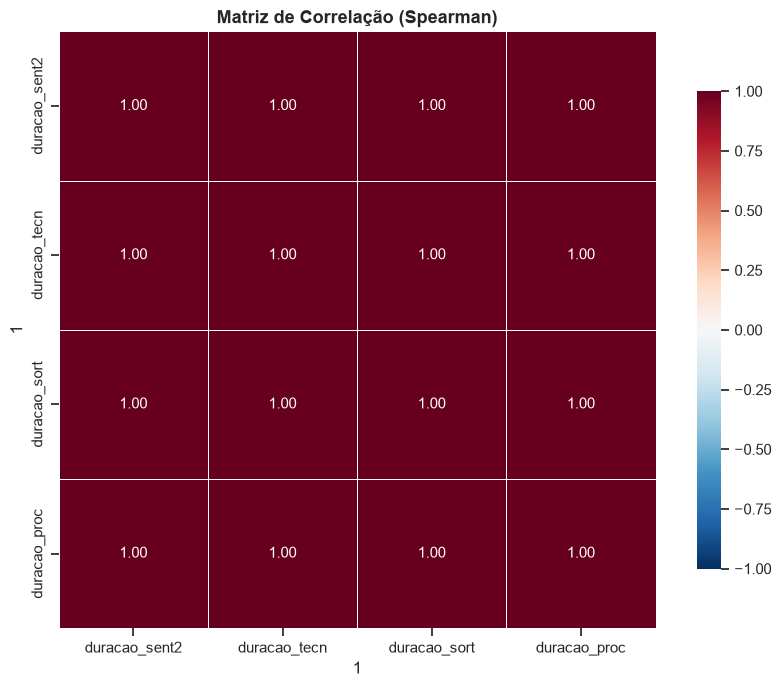


Correlações mais fortes (|r| > 0,5, excluindo diagonal):
  duracao_sent2             × duracao_tecn             : r = 1.000
  duracao_sent2             × duracao_sort             : r = 1.000
  duracao_sent2             × duracao_proc             : r = 1.000
  duracao_tecn              × duracao_sort             : r = 1.000
  duracao_tecn              × duracao_proc             : r = 1.000
  duracao_sort              × duracao_proc             : r = 1.000


In [23]:
# ── Matriz de correlação de Spearman ─────────────────────────────────────

COLS_CORR = [c for c in ['duracao_sent2', 'duracao_tecn', 'duracao_sort', 'duracao_proc']
             if c in dados.columns]

print('MATRIZ DE CORRELAÇÃO — variáveis de duração (Spearman)')
corr_matrix = matriz_correlacao(dados, variaveis=COLS_CORR, metodo='spearman')

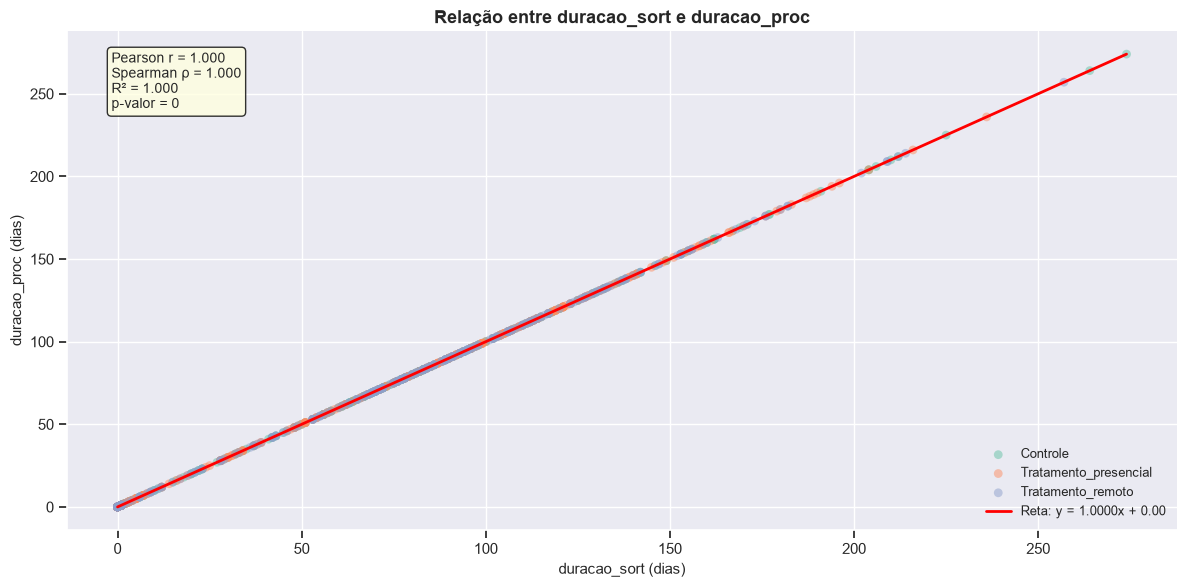


Correlação de Pearson: 1.0000 — forte e positiva
Correlação de Spearman: 1.0000
R² = 1.0000 — 100.0% da variação em duracao_proc explicada por duracao_sort
p-valor = 0 → significativo (α=0,05)


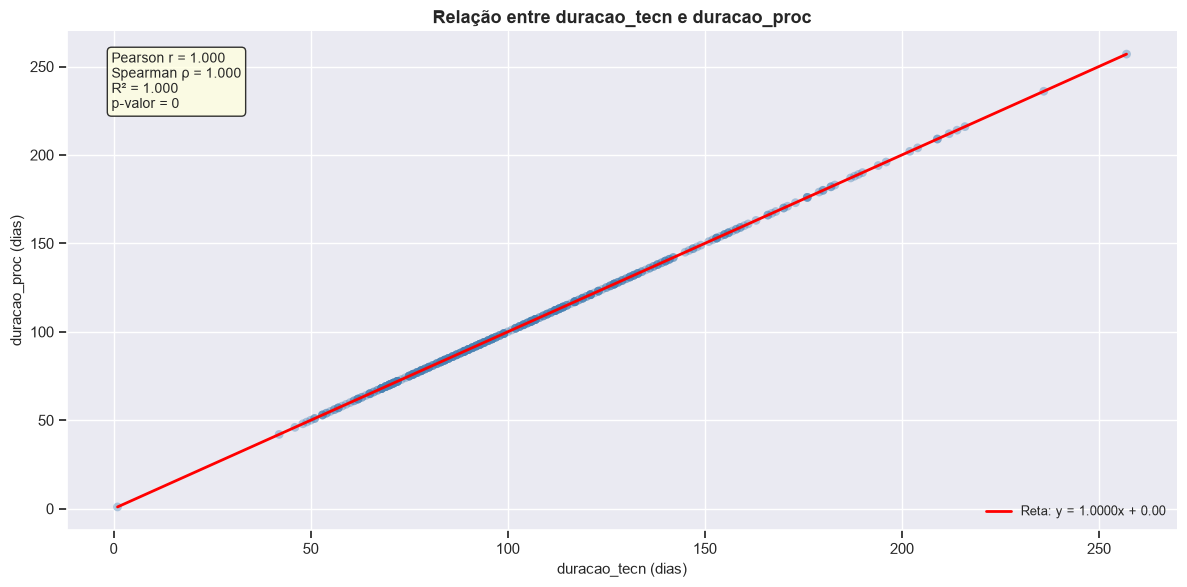


Correlação de Pearson: 1.0000 — forte e positiva
Correlação de Spearman: 1.0000
R² = 1.0000 — 100.0% da variação em duracao_proc explicada por duracao_tecn
p-valor = 0 → significativo (α=0,05)


In [24]:
# ── Dispersão: duracao_sort × duracao_proc (colorido por grupo) ───────────

if {'duracao_sort', 'duracao_proc'}.issubset(dados.columns):
    analise_dispersao(
        dados,
        var_x='duracao_sort', var_y='duracao_proc',
        unidade_x='dias', unidade_y='dias',
        cor_grupo='grupo'
    )

# ── Dispersão: duracao_tecn × duracao_proc ────────────────────────────────
if {'duracao_tecn', 'duracao_proc'}.issubset(dados.columns):
    analise_dispersao(
        dados,
        var_x='duracao_tecn', var_y='duracao_proc',
        unidade_x='dias', unidade_y='dias'
    )

## 16. O Tempo de Tramitação Segue Distribuição Normal?

**Objetivo:** avaliar a normalidade de `duracao_proc` com testes formais (Shapiro-Wilk e D'Agostino-Pearson) e inspeção visual (Q-Q plot).  
A escolha entre testes **paramétricos** (t, ANOVA) e **não paramétricos** (Mann-Whitney, Kruskal-Wallis) depende do resultado.

> **Atenção (do ODT):** o ODT de limitações alerta que distribuições de tempo processual são tipicamente *right-skewed* (assimétricas à direita), o que viola a premissa de normalidade. Por isso, os testes não paramétricos são preferidos neste estudo.

TESTES DE NORMALIDADE — duracao_proc
  N (amostra para teste)  : 500
  Shapiro-Wilk            : W = 0.9714  |  p = 2.608e-08
  D'Agostino-Pearson      : K_quadrado = 3.0933  |  p = 0.213
  → Shapiro-Wilk: rejeita normalidade (p < 0,05).
  → D'Agostino-Pearson: não rejeita normalidade (p ≥ 0,05).


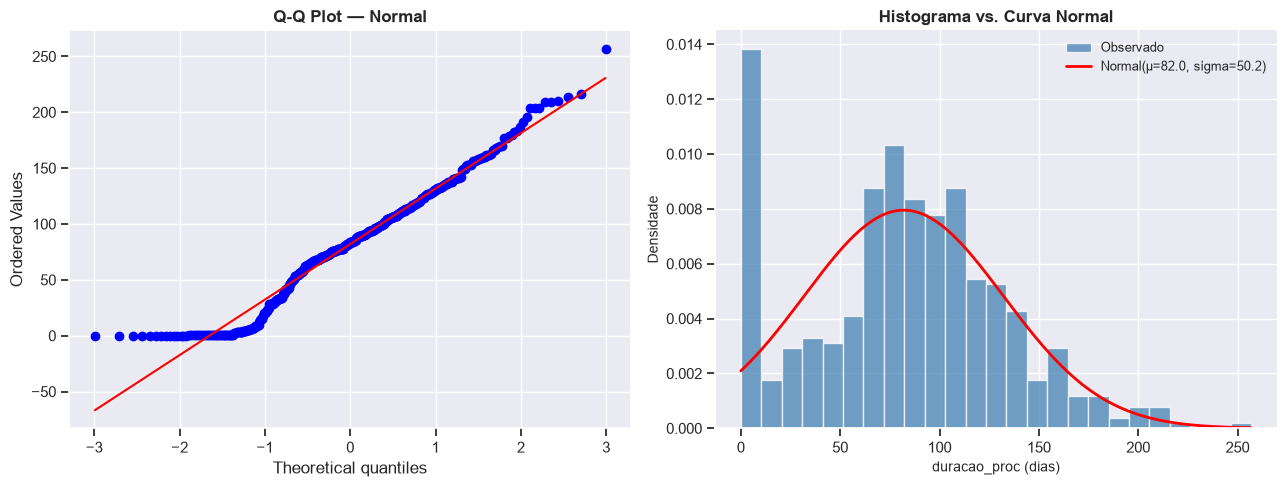


→ Interpretação: dados de tempo processual são tipicamente assimétricos
  à direita (right-skewed). Prefira testes não paramétricos (Mann-Whitney,
  Kruskal-Wallis) e análise de sobrevivência (Kaplan-Meier).


In [30]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Amostrar até 500 obs. para evitar o problema de amostras grandes
#    (onde qualquer pequena assimetria rejeita a normalidade).
# 2) Aplicar Shapiro-Wilk e D'Agostino-Pearson.
# 3) Gerar Q-Q plot e histograma para inspeção visual.
# ───────────────────────────────────────────────────────────────────────────

if 'duracao_proc' in dados.columns:
    serie_completa = dados['duracao_proc'].dropna()
    # Limitar amostra para os testes formais
    amostra = serie_completa.sample(min(len(serie_completa), 500), random_state=42)

    # Testes formais de normalidade
    sw_stat, sw_p   = stats.shapiro(amostra)
    dag_stat, dag_p = stats.normaltest(amostra)

    print('TESTES DE NORMALIDADE — duracao_proc')
    print('=' * 55)
    print(f'  N (amostra para teste)  : {len(amostra)}')
    print(f'  Shapiro-Wilk            : W = {sw_stat:.4f}  |  p = {sw_p:.4g}')
    print(f'  D\'Agostino-Pearson      : K_quadrado = {dag_stat:.4f}  |  p = {dag_p:.4g}')

    for nome, p in [('Shapiro-Wilk', sw_p), ("D'Agostino-Pearson", dag_p)]:
        if p < 0.05:
            print(f'  → {nome}: rejeita normalidade (p < 0,05).')
        else:
            print(f'  → {nome}: não rejeita normalidade (p ≥ 0,05).')

    # Visualizações
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Q-Q plot
    stats.probplot(amostra, dist='norm', plot=axes[0])
    axes[0].set_title('Q-Q Plot — Normal', fontsize=12, fontweight='bold')

    # Histograma com curva normal sobreposta
    mu, sigma = amostra.mean(), amostra.std()
    x_norm = np.linspace(amostra.min(), amostra.max(), 200)
    axes[1].hist(amostra, bins=25, density=True, color='steelblue',
                 edgecolor='white', alpha=0.75, label='Observado')
    axes[1].plot(x_norm, stats.norm.pdf(x_norm, mu, sigma),
                 'r-', linewidth=2, label=f'Normal(μ={mu:.1f}, sigma={sigma:.1f})')
    axes[1].set_xlabel('duracao_proc (dias)', fontsize=10)
    axes[1].set_ylabel('Densidade', fontsize=10)
    axes[1].set_title('Histograma vs. Curva Normal', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    print('\n→ Interpretação: dados de tempo processual são tipicamente assimétricos')
    print('  à direita (right-skewed). Prefira testes não paramétricos (Mann-Whitney,')
    print('  Kruskal-Wallis) e análise de sobrevivência (Kaplan-Meier).')

## 17. Testes de Hipóteses — do Simples ao Completo

**Objetivo:** formalizar os principais testes do estudo, da hipótese mais simples (proporção de encerramento) à comparação completa entre grupos.

### Testes realizados:
1. **Teste binomial (z)** — a proporção de processos encerrados difere de 50%?
2. **Mann-Whitney** — o tempo de tramitação difere entre processos com e sem acordo?
3. **Kruskal-Wallis** — o tempo difere entre os três grupos experimentais? *(já realizado na seção 13)*

In [31]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Teste binomial (z): proporção de encerrados vs. H₀: p = 0,5.
# 2) Mann-Whitney: acordo na AC → tempo de tramitação.
# ───────────────────────────────────────────────────────────────────────────

# ── Teste 1: proporção de encerrados ──────────────────────────────────────
if 'status_norm' in dados.columns:
    n   = dados['status_norm'].notna().sum()
    k   = (dados['status_norm'] == 'Encerrado').sum()
    p0  = 0.50                         # hipótese nula: 50% de encerramento
    p_h = k / n
    se  = np.sqrt(p0 * (1 - p0) / n)
    z   = (p_h - p0) / se
    p_val_z = 2 * (1 - stats.norm.cdf(abs(z)))

    print('TESTE Z — Proporção de Processos Encerrados')
    print('=' * 55)
    print(f'  H₀: p(encerrado) = {p0}')
    print(f'  H₁: p(encerrado) ≠ {p0}')
    print(f'  n = {n}  |  k encerrados = {k}  |  p̂ = {p_h:.3f}')
    print(f'  z = {z:.3f}  |  p-valor = {p_val_z:.4g}')
    print(f'  → {"Rejeita" if p_val_z < 0.05 else "Não rejeita"} H₀ (α = 0,05)')

# ── Teste 2: tempo de tramitação — acordo vs. sem acordo na AC ─────────────
if {'teve_acordo_na_ac', 'duracao_proc'}.issubset(dados.columns):
    com_acordo = dados.loc[dados['teve_acordo_na_ac'] == 'Sim',  'duracao_proc'].dropna()
    sem_acordo = dados.loc[dados['teve_acordo_na_ac'] == 'Não',  'duracao_proc'].dropna()

    # Adaptar para possíveis variações de encoding do 'Não'
    if len(sem_acordo) == 0:
        sem_acordo = dados.loc[
            ~dados['teve_acordo_na_ac'].isin(['Sim', np.nan]),
            'duracao_proc'
        ].dropna()

    if len(com_acordo) > 1 and len(sem_acordo) > 1:
        U, p_mw = stats.mannwhitneyu(com_acordo, sem_acordo, alternative='two-sided')

        print('\nTESTE MANN-WHITNEY — Tempo por Resultado do Acordo na AC')
        print('=' * 55)
        print(f'  H₀: medianas iguais (com acordo vs. sem acordo na AC).')
        print(f'  H₁: medianas diferentes.')
        print(f'  n(com acordo) = {len(com_acordo)}  |  mediana = {com_acordo.median():.1f} dias')
        print(f'  n(sem acordo) = {len(sem_acordo)}  |  mediana = {sem_acordo.median():.1f} dias')
        print(f'  U = {U:.2f}  |  p-valor = {p_mw:.4g}')
        print(f'  → {"Rejeita" if p_mw < 0.05 else "Não rejeita"} H₀ (α = 0,05)')
    else:
        print('(Dados insuficientes para o teste de acordo na AC)')

TESTE Z — Proporção de Processos Encerrados
  H₀: p(encerrado) = 0.5
  H₁: p(encerrado) ≠ 0.5
  n = 943  |  k encerrados = 734  |  p̂ = 0.778
  z = 17.096  |  p-valor = 0
  → Rejeita H₀ (α = 0,05)

TESTE MANN-WHITNEY — Tempo por Resultado do Acordo na AC
  H₀: medianas iguais (com acordo vs. sem acordo na AC).
  H₁: medianas diferentes.
  n(com acordo) = 17  |  mediana = 63.0 dias
  n(sem acordo) = 852  |  mediana = 81.0 dias
  U = 6477.00  |  p-valor = 0.4556
  → Não rejeita H₀ (α = 0,05)


## 18. Ajuste de Distribuições Probabilísticas

**Objetivo:** identificar qual distribuição paramétrica descreve melhor o tempo de tramitação (`duracao_proc`), comparando candidatos por **AIC** (Critério de Informação de Akaike).

**Distribuições candidatas:**
- **Log-Normal** — frequentemente adequada para tempos processuais.
- **Gamma** — generalização da exponencial; modela variáveis de tempo não negativas.
- **Weibull** — amplamente usada em análise de sobrevivência e confiabilidade.
- **Exponencial** — caso mais simples; taxa de encerramento constante.

> **Como interpretar:** menor AIC → melhor ajuste relativo (penalizado pelo número de parâmetros).

AJUSTE DE DISTRIBUIÇÕES — duracao_proc (ordenado por AIC)


,Distribuição,AIC,BIC,LogLik
0,Weibull,9585.77,9600.19,-4789.89
1,Gamma,9611.60,9626.02,-4802.80
2,Log-Normal,9612.54,9626.96,-4803.27
3,Exponencial,9753.63,9763.24,-4874.81



→ Melhor ajuste (menor AIC): Weibull


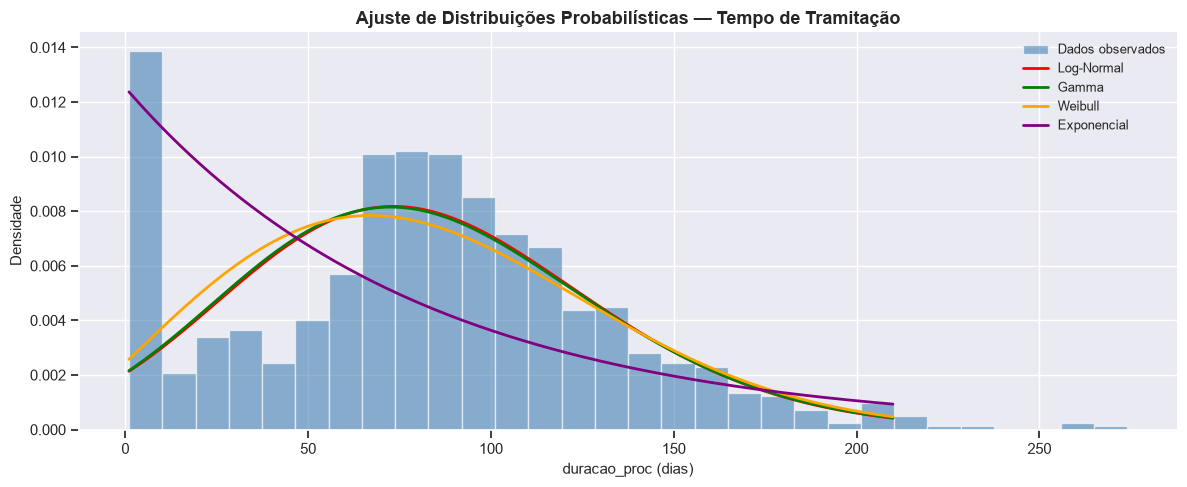

In [32]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Extrair valores positivos finitos de duracao_proc.
# 2) Ajustar cada distribuição candidata (MLE).
# 3) Calcular log-verossimilhança, AIC e BIC.
# 4) Comparar graficamente os ajustes.
# ───────────────────────────────────────────────────────────────────────────

if 'duracao_proc' in dados.columns:
    x = dados['duracao_proc'].dropna().values
    x = x[np.isfinite(x) & (x > 0)]

    candidatos = {
        'Log-Normal'  : stats.lognorm,
        'Gamma'       : stats.gamma,
        'Weibull'     : stats.weibull_min,
        'Exponencial' : stats.expon,
    }

    resultados, params_ajust = [], {}
    for nome, dist in candidatos.items():
        params = dist.fit(x)
        params_ajust[nome] = params
        loglik = np.sum(dist.logpdf(x, *params))
        k   = len(params)
        n   = len(x)
        aic = 2 * k - 2 * loglik
        bic = np.log(n) * k - 2 * loglik
        resultados.append({'Distribuição': nome, 'AIC': round(aic, 2),
                           'BIC': round(bic, 2), 'LogLik': round(loglik, 2)})

    tabela_fit = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
    print('AJUSTE DE DISTRIBUIÇÕES — duracao_proc (ordenado por AIC)')
    print('=' * 60)
    display(tabela_fit)

    melhor = tabela_fit.loc[0, 'Distribuição']
    print(f'\n→ Melhor ajuste (menor AIC): {melhor}')

    # Gráfico comparativo de ajustes
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(x, bins=30, density=True, color='steelblue', edgecolor='white',
            alpha=0.6, label='Dados observados')

    x_range = np.linspace(x.min(), np.percentile(x, 99), 300)
    cores = ['red', 'green', 'orange', 'purple']
    for (nome, dist), cor in zip(candidatos.items(), cores):
        params = params_ajust[nome]
        ax.plot(x_range, dist.pdf(x_range, *params), color=cor,
                linewidth=2, label=nome)

    ax.set_xlabel('duracao_proc (dias)', fontsize=11)
    ax.set_ylabel('Densidade', fontsize=11)
    ax.set_title('Ajuste de Distribuições Probabilísticas — Tempo de Tramitação',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

## 19. Modelos de Regressão — Tempo de Tramitação e Desfecho do Acordo

**Objetivo:** ajustar dois modelos complementares:
1. **Regressão linear (OLS):** `duracao_proc` em função das durações intermediárias e indicadores de acordo.
2. **Regressão logística:** probabilidade de encerramento (`evento`) em função das mesmas covariáveis.

> **Atenção:** interprete coeficientes e significância sempre com leitura substantiva do contexto jurídico.

In [35]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Preparar variáveis preditoras e codificar dummies.
# 2) Ajustar OLS (variável resposta: duracao_proc).
# 3) Ajustar Logit (variável resposta: evento = encerrado).
# 4) Exibir resumo dos modelos.
# ───────────────────────────────────────────────────────────────────────────

if TEM_STATSMODELS and sm is not None:

    # ── Preparação das variáveis ───────────────────────────────────────────
    colunas_modelo = ['duracao_proc', 'duracao_sort', 'duracao_sent2', 'evento']
    cat_dummies    = [c for c in ['grupo'] if c in dados.columns]

    df_reg = dados[colunas_modelo + cat_dummies].dropna(subset=['duracao_proc', 'evento']).copy()

    # Dummies para grupo experimental (referência: Controle)
    for cat in cat_dummies:
        df_reg = pd.get_dummies(df_reg, columns=[cat], drop_first=True, dtype=float)

    # Colunas preditoras para OLS
    preditoras = [c for c in df_reg.columns
                  if c not in ['duracao_proc', 'evento', 'duracao_sort', 'duracao_sent2'] and df_reg[c].notna().sum() > 20]

    df_reg_ols = df_reg[['duracao_proc'] + preditoras].dropna()

    if len(df_reg_ols) > 30:
        y_ols = df_reg_ols['duracao_proc']
        X_ols = sm.add_constant(df_reg_ols[preditoras])
        ols   = sm.OLS(y_ols, X_ols).fit()
        print('REGRESSÃO LINEAR (OLS) — variável resposta: duracao_proc')
        print(ols.summary())
    else:
        print('Dados insuficientes para OLS.')

    # ── Regressão logística ────────────────────────────────────────────────
    df_reg_log = df_reg[['evento'] + preditoras].dropna()

    if df_reg_log['evento'].nunique() == 2 and len(df_reg_log) > 50:
        y_log = df_reg_log['evento']
        X_log = sm.add_constant(df_reg_log[preditoras])
        logit = sm.Logit(y_log, X_log).fit(disp=False)
        print('\nREGRESSÃO LOGÍSTICA — variável resposta: evento (encerrado=1)')
        print(logit.summary())
    else:
        print('Dados insuficientes ou sem variação na resposta para Logit.')

else:
    print('statsmodels não disponível. Instale com: pip install statsmodels')

REGRESSÃO LINEAR (OLS) — variável resposta: duracao_proc
                            OLS Regression Results                            
Dep. Variable:           duracao_proc   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.5310
Date:                Thu, 08 Oct 2026   Prob (F-statistic):              0.588
Time:                        00:41:33   Log-Likelihood:                -5048.5
No. Observations:                 943   AIC:                         1.010e+04
Df Residuals:                     940   BIC:                         1.012e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

## 20. Análise de Sobrevivência — Kaplan-Meier por Grupo Experimental

**Objetivo:** modelar o **tempo até o encerramento** do processo usando o estimador de Kaplan-Meier, que trata adequadamente os processos censurados (ativos ao fim da janela de observação).

**Interpretação da curva:**
- Eixo y = probabilidade de o processo ainda estar em tramitação (não encerrado).
- A curva cai quando um processo é encerrado; platos indicam períodos sem eventos (ou censuras).
- **Mediana de Kaplan-Meier** = tempo em que 50% dos processos foram encerrados.
- Curvas mais à esquerda indicam encerramento mais rápido.

**Teste log-rank:** compara as curvas de sobrevivência entre grupos (H₀: curvas iguais).

> **Contexto (do ODT):** a janela de 218 dias e a presença de ~22% de processos censurados tornam o Kaplan-Meier imprescindível — a média simples subestima o tempo real dos processos ativos.

Biblioteca lifelines não disponível.
Instale com: pip install lifelines



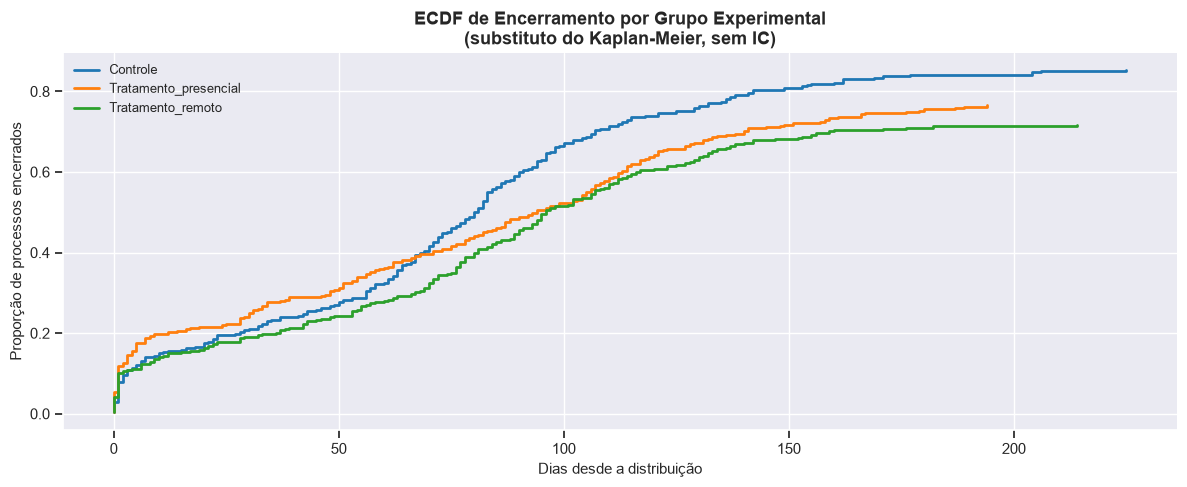

In [36]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Verificar disponibilidade da biblioteca lifelines.
# 2) Ajustar KaplanMeierFitter para cada grupo.
# 3) Plotar curvas de sobrevivência com IC 95%.
# 4) Aplicar teste log-rank (pairwise) entre grupos.
# 5) Exibir medianas por grupo.
# ───────────────────────────────────────────────────────────────────────────

if TEM_LIFELINES and KaplanMeierFitter is not None:

    if {'duracao_proc', 'status_norm', 'grupo'}.issubset(dados.columns):

        km_df = dados[['duracao_proc', 'evento', 'grupo']].dropna(
            subset=['duracao_proc', 'evento', 'grupo']
        ).copy()

        grupos_km = km_df['grupo'].unique()
        paleta_km = dict(zip(grupos_km, sns.color_palette('Set1', len(grupos_km))))

        fig, ax = plt.subplots(figsize=(12, 6))

        medianas = {}
        for grupo in sorted(grupos_km):
            sub = km_df[km_df['grupo'] == grupo]
            kmf = KaplanMeierFitter()
            kmf.fit(
                durations=sub['duracao_proc'],
                event_observed=sub['evento'],
                label=str(grupo)
            )
            kmf.plot_survival_function(
                ax=ax, ci_show=True, color=paleta_km[grupo], linewidth=2
            )
            medianas[grupo] = kmf.median_survival_time_

        ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.7,
                   label='S(t) = 0,50 (mediana)')
        ax.set_xlabel('Dias desde a distribuição', fontsize=11)
        ax.set_ylabel('Probabilidade de permanência em tramitação', fontsize=11)
        ax.set_title('Curvas de Kaplan-Meier por Grupo Experimental\n'
                     '(processos censurados incluídos)', fontsize=13, fontweight='bold')
        ax.legend(fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

        # Medianas de sobrevivência por grupo
        print('\nMediana de Kaplan-Meier por grupo (dias até encerramento):')
        print('=' * 55)
        for grupo, med in sorted(medianas.items(), key=lambda x: x[1]):
            print(f'  {str(grupo):30s}: {med:.1f} dias')

        # Teste log-rank entre pares de grupos
        if logrank_test is not None:
            print('\nTeste Log-Rank (comparações par a par):')
            print('=' * 55)
            from itertools import combinations
            for g1, g2 in combinations(sorted(grupos_km), 2):
                sub1 = km_df[km_df['grupo'] == g1]
                sub2 = km_df[km_df['grupo'] == g2]
                resultado = logrank_test(
                    sub1['duracao_proc'], sub2['duracao_proc'],
                    event_observed_A=sub1['evento'],
                    event_observed_B=sub2['evento']
                )
                sig = '* sig.' if resultado.p_value < 0.05 else 'n.s.'
                print(f'  {g1} vs {g2}:')
                print(f'    p-valor = {resultado.p_value:.4g}  {sig}')
else:
    print('Biblioteca lifelines não disponível.')
    print('Instale com: pip install lifelines')
    print()

    # Fallback: ECDF simples por grupo
    if {'duracao_proc', 'grupo', 'evento'}.issubset(dados.columns):
        fig, ax = plt.subplots(figsize=(12, 5))
        for grupo, sub in dados.dropna(subset=['grupo', 'duracao_proc']).groupby('grupo', observed=True):
            encerrados = sub.loc[sub['evento'] == 1, 'duracao_proc'].sort_values()
            ecdf = np.arange(1, len(encerrados) + 1) / len(sub)  # proporção de encerrados
            ax.step(encerrados.values, ecdf, where='post', linewidth=2, label=str(grupo))

        ax.set_xlabel('Dias desde a distribuição', fontsize=11)
        ax.set_ylabel('Proporção de processos encerrados', fontsize=11)
        ax.set_title('ECDF de Encerramento por Grupo Experimental\n'
                     '(substituto do Kaplan-Meier, sem IC)', fontsize=13, fontweight='bold')
        ax.legend(fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

## 21. Janela de Observação e Truncamento Temporal

**Objetivo:** avaliar o impacto da janela de 218 dias sobre as estimativas de duração, identificar o período de distribuição dos processos e visualizar a ECDF com a marcação do limite da janela.

**Contexto (do ODT):**  
> *"A comparação entre a média histórica pré-intervenção (106,8 dias) e a média durante o experimento (75,2 dias) pressupõe que nada mais mudou no tribunal durante o período. A média informada de 75,2 dias engloba as três modalidades de rito simultaneamente. Sem a decomposição dessa média por grupo, não é possível aferir a relação de causalidade."*

JANELA DE OBSERVAÇÃO
  Início da distribuição : 2026-01-01
  Fim da distribuição    : 2026-08-03
  Amplitude (dias)       : 214
  Janela relatada no ODT : 218 dias

Percentis de duracao_proc:
count   943.00
mean     78.50
std      51.20
min       0.00
25%      42.00
50%      80.00
75%     110.50
90%     141.00
95%     162.00
max     274.00
Name: duracao_proc, dtype: float64


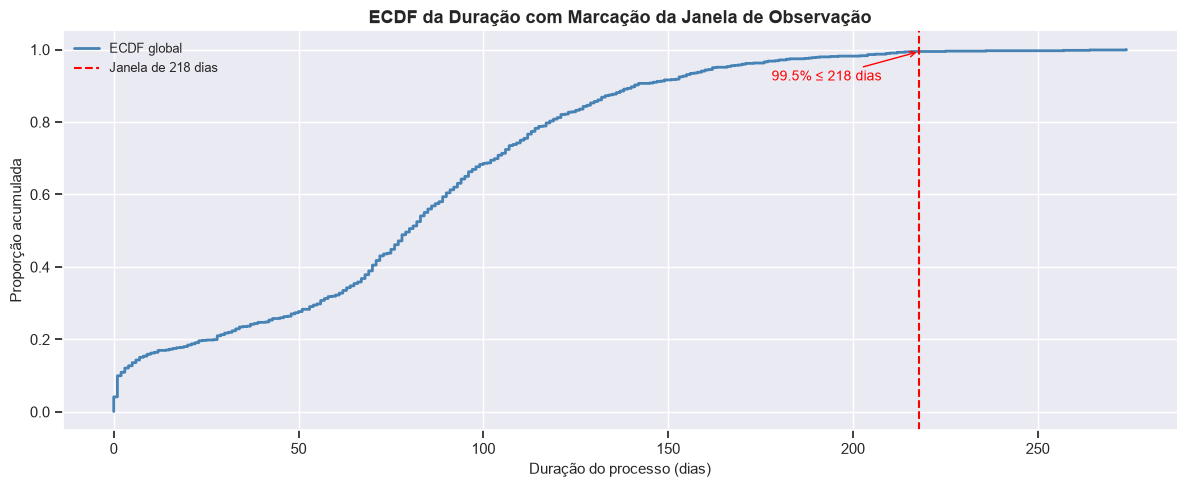


Média vs. Mediana de duracao_proc por grupo (todos os processos):


,n,media,mediana,p90
grupo,,,,
Controle,314,77.00,77.00,141.00
Tratamento_presencial,315,77.50,84.00,140.60
Tratamento_remoto,314,80.90,81.00,141.40



→ Interprete com cautela: a média é influenciada pelos processos longos
  (maioria dos quais são censurados). A mediana é mais robusta.


In [37]:
# ── Passo a passo desta célula ─────────────────────────────────────────────
# 1) Calcular o período de distribuição observado.
# 2) Verificar quantos processos estão dentro/fora da janela de 218 dias.
# 3) Plotar ECDF com marcação da janela de observação.
# 4) Comparar médias simples vs. medianas por grupo.
# ───────────────────────────────────────────────────────────────────────────

if {'dt_distribuicao', 'duracao_proc'}.issubset(dados.columns):

    dt_ini = dados['dt_distribuicao'].min()
    dt_fim = dados['dt_distribuicao'].max()
    janela_calc = (dt_fim - dt_ini).days if pd.notna(dt_ini) and pd.notna(dt_fim) else np.nan

    print('JANELA DE OBSERVAÇÃO')
    print('=' * 55)
    print(f'  Início da distribuição : {dt_ini.date() if pd.notna(dt_ini) else "?"}')
    print(f'  Fim da distribuição    : {dt_fim.date() if pd.notna(dt_fim) else "?"}')
    print(f'  Amplitude (dias)       : {janela_calc}')
    print(f'  Janela relatada no ODT : {JANELA_DIAS} dias')
    print()

    # Percentis da duração
    print('Percentis de duracao_proc:')
    print(dados['duracao_proc'].describe(percentiles=[.25, .5, .75, .9, .95]).round(1))

    # ECDF global
    fig, ax = plt.subplots(figsize=(12, 5))
    serie_ord = dados['duracao_proc'].dropna().sort_values()
    ecdf_y    = np.arange(1, len(serie_ord) + 1) / len(serie_ord)

    ax.step(serie_ord.values, ecdf_y, where='post', color='steelblue',
            linewidth=2, label='ECDF global')
    ax.axvline(JANELA_DIAS, color='red', linestyle='--', linewidth=1.5,
               label=f'Janela de {JANELA_DIAS} dias')

    # Proporção de processos dentro da janela
    prop_dentro = (serie_ord <= JANELA_DIAS).mean()
    ax.annotate(f'{prop_dentro*100:.1f}% ≤ {JANELA_DIAS} dias',
                xy=(JANELA_DIAS, prop_dentro), xytext=(JANELA_DIAS - 40, prop_dentro - 0.08),
                fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

    ax.set_xlabel('Duração do processo (dias)', fontsize=11)
    ax.set_ylabel('Proporção acumulada', fontsize=11)
    ax.set_title('ECDF da Duração com Marcação da Janela de Observação',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    # Médias vs. medianas desagregadas por grupo
    if 'grupo' in dados.columns:
        print('\nMédia vs. Mediana de duracao_proc por grupo (todos os processos):')
        display(
            dados.groupby('grupo', observed=True)['duracao_proc']
            .agg(n='count', media='mean', mediana='median',
                 p90=lambda s: s.quantile(.9))
            .round(1)
        )
        print('\n→ Interprete com cautela: a média é influenciada pelos processos longos')
        print('  (maioria dos quais são censurados). A mediana é mais robusta.')

## 22. Complementação Metodológica — Extensão do Pipeline

**Objetivo:** preparar o dataset para integração com bases externas (ex.: DataJud / TJRN) e verificar o estado de prontidão para análises de escala ampliada, seguindo o checklist do arquivo-modelo `rafaelcc_ed1.ipynb`.

Esta seção permanece como **bloco de extensão** — não executa análises adicionais, mas documenta o ponto de acoplamento para trabalhos futuros.

In [38]:
# ── Checklist de prontidão para extensão do pipeline ─────────────────────

checklist = {
    '1_chave_de_linkage_definida'         : 'numero_do_processo' in dados.columns,
    '2_variavel_tempo_harmonizada'        : 'duracao_proc' in dados.columns,
    '3_status_evento_harmonizado'         : 'status_norm' in dados.columns,
    '4_grupos_experimentais_harmonizados' : 'grupo' in dados.columns,
    '5_indicador_censura_criado'          : 'evento' in dados.columns,
    '6_dataset_limpo_exportado'           : (SAIDA_DIR / 'estcaso_4jec_natal_limpo.xlsx').exists(),
    '7_lifelines_disponivel'              : TEM_LIFELINES,
    '8_statsmodels_disponivel'            : TEM_STATSMODELS,
}

check_df = pd.Series(checklist, name='status')
check_df = check_df.to_frame()
check_df['avaliação'] = check_df['status'].map({True: 'PRONTO', False: 'PENDENTE'})

print('CHECKLIST PARA EXTENSÃO DO PIPELINE')
print('=' * 55)
display(check_df)

# Espaço reservado para integração com bases externas
# ─────────────────────────────────────────────────────────────────────────────
# Para acoplamento com DataJud ou outras bases do TJRN:
#   1) Carregar base externa com a mesma chave 'numero_do_processo'.
#   2) Fazer merge com 'dados' via pd.merge(dados, base_ext, on='numero_do_processo').
#   3) Repetir as análises das seções 13-20 com as novas variáveis.
# ─────────────────────────────────────────────────────────────────────────────
print('\nBloco de extensão documentado. Pronto para acoplamento com bases externas.')

CHECKLIST PARA EXTENSÃO DO PIPELINE


,status,avaliação
1_chave_de_linkage_definida,True,PRONTO
2_variavel_tempo_harmonizada,True,PRONTO
3_status_evento_harmonizado,True,PRONTO
4_grupos_experimentais_harmonizados,True,PRONTO
5_indicador_censura_criado,True,PRONTO
6_dataset_limpo_exportado,True,PRONTO
7_lifelines_disponivel,False,PENDENTE
8_statsmodels_disponivel,True,PRONTO



Bloco de extensão documentado. Pronto para acoplamento com bases externas.


## 23. Síntese e Conclusões

**Objetivo:** consolidar os principais achados do estudo de caso em um resumo automático e orientar as conclusões substantivas.

---

### Questões norteadoras

**1. Perfil dos processos**  
Como se distribui o tempo de tramitação? Quais grupos concentram mais processos encerrados?

**2. Eficácia da conciliação obrigatória**  
Os grupos com AC obrigatória (presencial e remota) apresentam menor tempo de tramitação em relação ao grupo controle?

**3. Acordos e tipo de sentença**  
A presença de acordo na AC está associada a um tipo diferente de sentença? O grupo com AC remota celebra mais acordos?

**4. Limitações metodológicas (do ODT)**  
- A janela de 218 dias introduz censura à direita significativa (~22% dos processos).
- A seleção de um único juizado limita a validade externa (generalização).
- O efeito Hawthorne e a contaminação intergrupos são riscos operacionais documentados.
- A média simples é enganosa sem desagregação por grupo e sem tratamento da censura.

In [39]:
# ── Resumo automático dos principais indicadores do estudo ────────────────

sintese = {}

# Tamanho da amostra e censura
if 'duracao_proc' in dados.columns:
    sintese['n_processos_total']    = int(dados['duracao_proc'].notna().sum())
    sintese['duracao_mediana_dias'] = float(dados['duracao_proc'].median())
    sintese['duracao_media_dias']   = round(float(dados['duracao_proc'].mean()), 1)
    sintese['duracao_p90_dias']     = float(dados['duracao_proc'].quantile(.9))

if 'status_norm' in dados.columns:
    n_total = dados['status_norm'].notna().sum()
    sintese['prop_encerrados_%'] = round((dados['status_norm'] == 'Encerrado').sum() / n_total * 100, 1)
    sintese['prop_censurados_%'] = round((dados['status_norm'] == 'Ativo').sum()     / n_total * 100, 1)

if 'grupo' in dados.columns:
    sintese['n_grupos_experimentais'] = int(dados['grupo'].nunique(dropna=True))
    for grupo, sub in dados.dropna(subset=['grupo']).groupby('grupo', observed=True):
        sintese[f'mediana_dias_{grupo}'] = float(sub['duracao_proc'].median())

if 'teve_acordo_na_ac' in dados.columns:
    n_ac = dados['teve_acordo_na_ac'].notna().sum()
    n_acordo = (dados['teve_acordo_na_ac'] == 'Sim').sum()
    sintese['prop_acordos_na_ac_%'] = round(n_acordo / n_ac * 100, 1) if n_ac > 0 else np.nan

print('RESUMO DO ESTUDO DE CASO — 4.º JEC DE NATAL/RN')
print('=' * 60)
for k, v in sintese.items():
    print(f'  {k:40s}: {v}')

print()
print('Arquivos exportados:')
print(f'  XLSX : {SAIDA_DIR / "estcaso_4jec_natal_limpo.xlsx"}')
print(f'  CSV  : {SAIDA_DIR / "estcaso_4jec_natal_limpo.csv"}')

RESUMO DO ESTUDO DE CASO — 4.º JEC DE NATAL/RN
  n_processos_total                       : 943
  duracao_mediana_dias                    : 80.0
  duracao_media_dias                      : 78.5
  duracao_p90_dias                        : 141.0
  prop_encerrados_%                       : 77.8
  prop_censurados_%                       : 22.2
  n_grupos_experimentais                  : 3
  mediana_dias_Controle                   : 77.0
  mediana_dias_Tratamento_presencial      : 84.0
  mediana_dias_Tratamento_remoto          : 81.0
  prop_acordos_na_ac_%                    : 2.0

Arquivos exportados:
  XLSX : e:\DADOS\Documents\AmbienteDeTrabalho\Projetos\notebook\dat\processado\estcaso_4jec_natal_limpo.xlsx
  CSV  : e:\DADOS\Documents\AmbienteDeTrabalho\Projetos\notebook\dat\processado\estcaso_4jec_natal_limpo.csv


## Referências

### Fontes de dados
- **Planilha de controle de processos** — 4.º JEC de Natal/RN, atualização de 07/10/2026.
- **Alencar, P.G.M.; Neves, C.B.** — *Eficácia da Conciliação Obrigatória na Tramitação Processual: um Experimento no 4.º JEC de Natal* (ENAJUS 2026, DOCX).
- **Documento de limitações** — *Limitações metodológicas do experimento 4.º JEC Natal* (ODT).

### Referências metodológicas
- **Pipeline-modelo:** `rafaelcc_ed1.ipynb`
- **Estudo-base:** `estcaso_ip.ipynb`

### Bibliotecas Python utilizadas
| Biblioteca | Finalidade |
|---|---|
| `pandas` | Manipulação e análise de dados |
| `numpy` | Computação numérica |
| `matplotlib` | Criação de gráficos |
| `seaborn` | Visualizações estatísticas |
| `scipy.stats` | Testes estatísticos e ajuste de distribuições |
| `statsmodels` | Regressão linear e logística, gráfico mosaico |
| `lifelines` | Análise de sobrevivência (Kaplan-Meier, log-rank) |

### Leituras de apoio
- Barbetta; Reis; Bornia (2025) — *Estatística para Cursos de Engenharia e Informática*, cap. 3.
- Moore; Notz; Fligner (2023) — *A Estatística Básica e sua Prática*, caps. 1–2.
- Kaplan, E.L.; Meier, P. (1958) — *Nonparametric estimation from incomplete observations*. JASA.
- Cox, D.R. (1972) — *Regression models and life-tables*. JRSS-B.

---

## Notas Finais

Este notebook apresentou um **pipeline analítico completo** para o estudo de caso do 4.º JEC de Natal/RN, estruturado em 23 seções que percorrem o ciclo:

```
preparação → limpeza → tipagem → auditoria → EDA categórica → EDA quantitativa
→ comparação de grupos → associação → correlação → normalidade
→ testes de hipóteses → ajuste de distribuições → regressão
→ sobrevivência (Kaplan-Meier) → janela de observação → síntese
```

**Principais lições metodológicas:**  
1. **Censura importa** — ignorar os processos ativos subestima o tempo de tramitação real.  
2. **Média ≠ mediana** — dados de tempo são assimétricos; prefira medianas e análise de sobrevivência.  
3. **Desagregar por grupo** — médias globais mascaram diferenças entre Controle e Tratamentos.  
4. **Correlação ≠ causalidade** — o delineamento experimental (com sorteio) fortalece a inferência, mas não elimina todos os confundidores.  
5. **Validade externa limitada** — resultados do 4.º JEC não se generalizam automaticamente para os demais juizados.